# Urdu & English Handwriting Recognition
## Semi-Supervised Learning + Generative Adversarial Networks

---

### Project Overview
This project implements a multilingual handwriting recognition system that:
- Recognizes handwritten **Urdu** and **English** characters and digits
- Detects whether a character belongs to **Urdu**, **English**, or an **Unknown** language
- Uses **GANs** to generate synthetic training data
- Uses **Semi-Supervised Learning** with pseudo-labeling to train on limited labeled data

---

### Core ML Techniques
| Technique | Purpose |
|-----------|---------|
| **Convolutional Neural Network (CNN)** | Extract visual features from character images |
| **Generative Adversarial Network (GAN)** | Generate synthetic handwriting samples for data augmentation |
| **Semi-Supervised Learning** | Train effectively with limited labeled data |
| **Pseudo-Labeling** | Assign labels to unlabeled data using model predictions |
| **Transfer Learning** | Shared encoder reused when adding new languages |

---

### Dataset Summary
| Dataset | Language | Images | Type |
|---------|----------|--------|------|
| UHaT (hazrat) | Urdu | 41,228 | Characters + Digits |
| Urdu 120K (mhassansaboor) | Urdu | 120,000 | Characters |
| English Chars (dhruvildave) | English | 3,410 | Characters |
| A-Z CSV (sachinpatel21) | English | 372,450 | Characters |
| Arabic (mloey1) | Unknown | 16,800 | Characters |
| Chinese (pascalbliem) | Unknown | ~10,000 | Characters |
| Hindi (suvooo) | Unknown | ~10,000 | Characters |

---

### Final Output
Given any handwritten character image the model predicts:
1. **Detected Language** — Urdu / English / Unknown
2. **Recognized Character** — with confidence score
3. **Top 3 predictions** — alternative possibilities

---
**Author:** Hasnain Sherazi | **Course:** Machine Learning — BS Artificial Intelligence


## Section 1 — Exploratory Data Analysis
Understanding all datasets before any training begins.

  DATASET AVAILABILITY
  FOUND    |  uhat          |  uhat-urdu-handwritten-text-dataset
  FOUND    |  urdu_120k     |  urdu-handwritten-characters-dataset-120k-images
  FOUND    |  eng_chars     |  english-handwritten-characters-dataset
  FOUND    |  az_csv        |  az-handwritten-alphabets-in-csv-format
  FOUND    |  arabic        |  ahcd1
  FOUND    |  chinese       |  handwritten-chinese-character-hanzi-datasets
  FOUND    |  hindi         |  hindi-character-recognition

  IMAGE COUNTS
  ✓ uhat          41,228 (28,328 chars + 6,606 digits train/test)
  ✓ urdu_120k     120,000
  ✓ eng_chars     3,410
  ✓ az_csv        372,450 (CSV format)
  ✓ arabic        16,800 (train + test)
  ✓ chinese       ~4,000,000 — 14,660 classes (only 15K used)
  ✓ hindi         ~92,000 — 92 classes (only 15K used)

  UHAT NPZ DETAIL
  Characters : 33,208 images
  Digits     : 8,020 images
  Image size : 28x28 grayscale
  Total      : 41,228

  ENGLISH CLASSES (dhruvildave)
  Digits 0-9 : ['0', '1', '2',

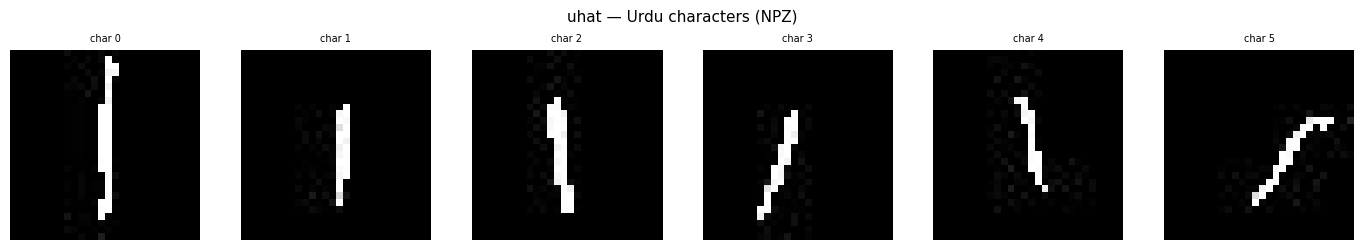

  uhat: 6 Urdu character samples


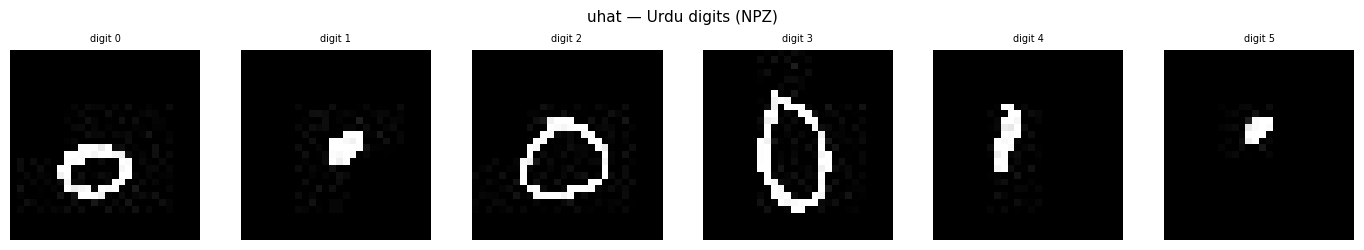

  uhat: 6 Urdu digit samples


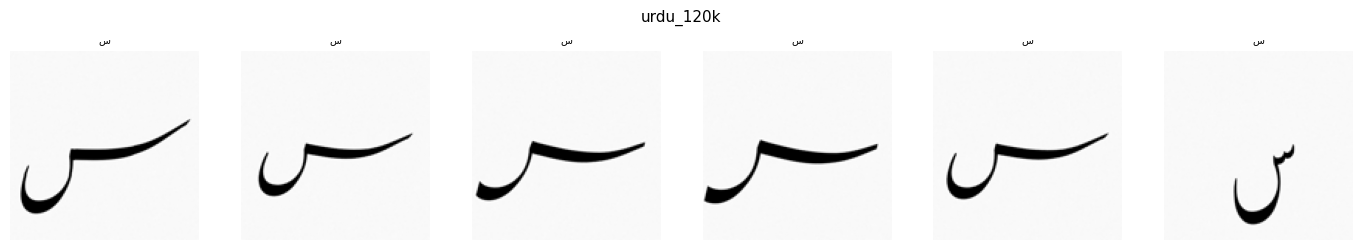

  urdu_120k: 6 samples shown


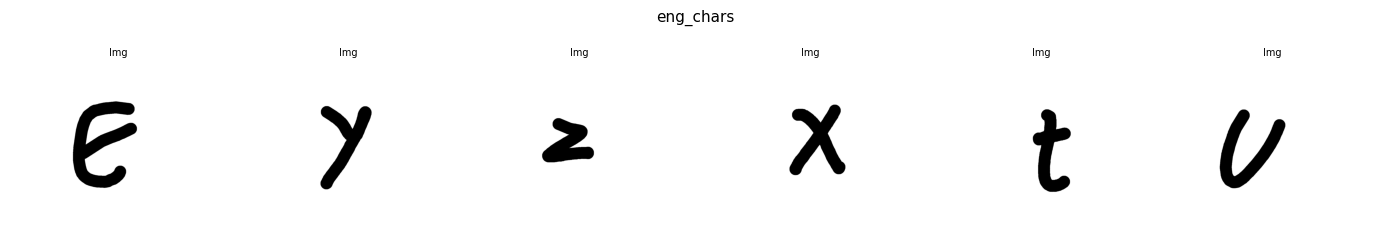

  eng_chars: 6 samples shown


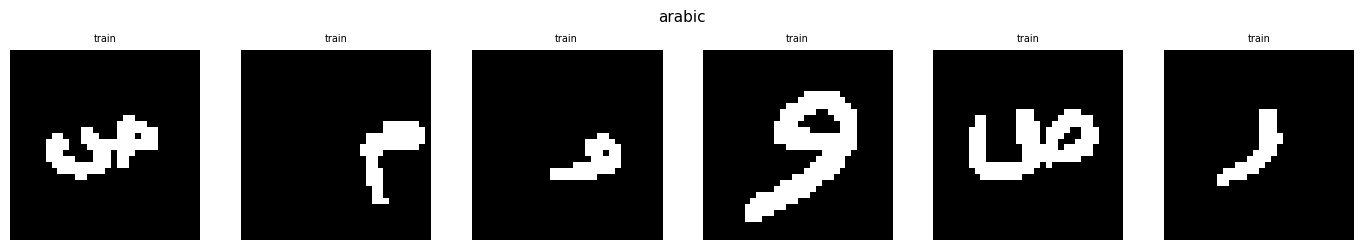

  arabic: 6 samples shown


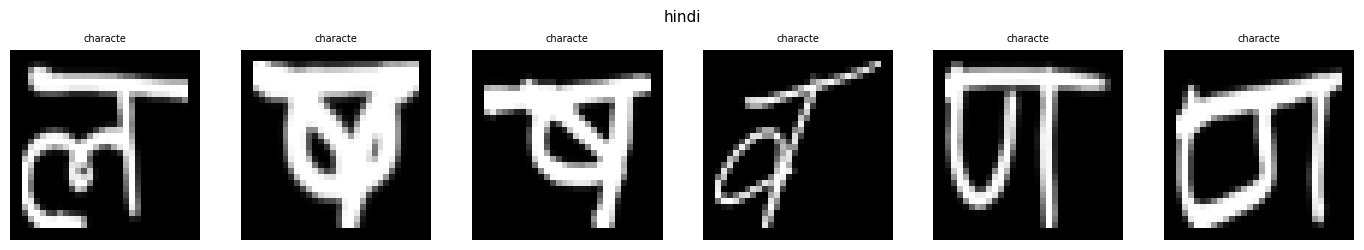

  hindi: 6 samples shown

  chinese: SKIPPED sample scan
  (4M images across 14,660 classes)
  Only 15,000 images will be used in training
  English-contaminated folders filtered in preprocessing

  DATASET SUMMARY FOR TRAINING

  Language  | Dataset          | Images used
  ----------|------------------|------------------
  Urdu      | UHaT NPZ         | 41,228
  Urdu      | Urdu 120K        | 120,000
  ----------|------------------|------------------
  English   | dhruvildave CSV  | 3,410 (A-Z+a-z+0-9)
  English   | A-Z CSV          | 372,450 (A-Z)
  ----------|------------------|------------------
  Unknown   | Arabic           | up to 15,000
  Unknown   | Chinese          | up to 15,000
  Unknown   | Hindi            | up to 15,000
  ----------|------------------|------------------
  NOTE: Dataloader caps each class at 2,000 images
  for balanced training regardless of dataset size.

Section 1 complete.


In [1]:
import os, cv2, numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import random
import warnings
warnings.filterwarnings('ignore')


BASE = Path('/kaggle/input/datasets')

# All datasets including new ones
DATASETS = {
    # Urdu
    'uhat'      : BASE / 'hazrat/uhat-urdu-handwritten-text-dataset',
    'urdu_120k' : BASE / 'mhassansaboor/urdu-handwritten-characters-dataset-120k-images',
    # English
    'eng_chars' : BASE / 'dhruvildave/english-handwritten-characters-dataset',
    'az_csv'    : BASE / 'sachinpatel21/az-handwritten-alphabets-in-csv-format',
    # Unknown class
    'arabic'    : BASE / 'mloey1/ahcd1',
    'chinese'   : BASE / 'pascalbliem/handwritten-chinese-character-hanzi-datasets',
    'hindi'     : BASE / 'suvooo/hindi-character-recognition',
}


# ── 1. Availability ────────────────────────────────────────
print("=" * 55)
print("  DATASET AVAILABILITY")
print("=" * 55)
for name, path in DATASETS.items():
    status = "FOUND  " if path.exists() else "MISSING"
    print(f"  {status}  |  {name:<12}  |  {path.name}")

# ── 2. Image counts ────────────────────────────────────────
print("\n" + "=" * 55)
print("  IMAGE COUNTS")
print("=" * 55)
KNOWN = {
    'uhat'     : '41,228 (28,328 chars + 6,606 digits train/test)',
    'urdu_120k': '120,000',
    'eng_chars': '3,410',
    'az_csv'   : '372,450 (CSV format)',
    'arabic'   : '16,800 (train + test)',
    'chinese'  : '~4,000,000 — 14,660 classes (only 15K used)',
    'hindi'    : '~92,000 — 92 classes (only 15K used)',
}
for name, info in KNOWN.items():
    path = DATASETS[name]
    status = '✓' if path.exists() else '✗'
    print(f"  {status} {name:<12}  {info}")

# ── 3. UHaT NPZ detail ────────────────────────────────────
print("\n" + "=" * 55)
print("  UHAT NPZ DETAIL")
print("=" * 55)
npz = list((DATASETS['uhat']).rglob('*.npz'))
if npz:
    data = np.load(npz[0], allow_pickle=True)
    total_chars  = (data['x_chars_train'].shape[0] +
                    data['x_chars_test'].shape[0])
    total_digits = (data['x_digits_train'].shape[0] +
                    data['x_digits_test'].shape[0])
    print(f"  Characters : {total_chars:,} images")
    print(f"  Digits     : {total_digits:,} images")
    print(f"  Image size : 28x28 grayscale")
    print(f"  Total      : {total_chars+total_digits:,}")

# ── 4. English classes ─────────────────────────────────────
print("\n" + "=" * 55)
print("  ENGLISH CLASSES (dhruvildave)")
print("=" * 55)
eng_csv = (BASE /
    'dhruvildave/english-handwritten-characters-dataset'
    / 'english.csv')
if eng_csv.exists():
    df   = pd.read_csv(eng_csv)
    lbls = sorted(df['label'].unique())
    digs = [l for l in lbls if str(l).isdigit()]
    uppr = [l for l in lbls if str(l).isupper()]
    lowr = [l for l in lbls if str(l).islower()]
    print(f"  Digits 0-9 : {digs}")
    print(f"  Upper  A-Z : {len(uppr)} classes")
    print(f"  Lower  a-z : {len(lowr)} classes")
    print(f"  Total      : {len(lbls)} classes ✓")

# ── 5. A-Z CSV info ────────────────────────────────────────
print("\n" + "=" * 55)
print("  A-Z CSV STRUCTURE")
print("=" * 55)
az_csvs = list((BASE/'sachinpatel21').rglob('*.csv'))
if az_csvs:
    df_az = pd.read_csv(az_csvs[0], header=None, nrows=5)
    print(f"  File   : {az_csvs[0].name}")
    print(f"  Rows   : 372,450")
    print(f"  Col 0  : label (0=A, 1=B ... 25=Z)")
    print(f"  Col 1-784 : pixel values (28x28 image)")
    print(f"  Sample labels: {df_az.iloc[:,0].tolist()}")

# ── 6. Sample images (skip Chinese — too large) ───────────
print("\n" + "=" * 55)
print("  SAMPLE IMAGES")
print("=" * 55)

def get_samples(path, n=6, max_scan=2000,
                skip_ascii=False):
    samples = []
    scanned = 0
    for root, dirs, files in os.walk(path):
        folder = os.path.basename(root)
        if skip_ascii and folder.isascii():
            continue
        for f in files:
            scanned += 1
            if scanned > max_scan:
                break
            if f.lower().endswith(('.png','.jpg')):
                samples.append(Path(root)/f)
        if scanned > max_scan:
            break
    if not samples:
        return []
    return random.sample(samples, min(n, len(samples)))

# UHaT from NPZ
npz = list((DATASETS['uhat']).rglob('*.npz'))
if npz:
    data = np.load(npz[0], allow_pickle=True)
    samp = data['x_chars_train'][:6]
    fig, axes = plt.subplots(1,6,figsize=(14,2.5))
    fig.suptitle("uhat — Urdu characters (NPZ)",
                 fontsize=11)
    for i,ax in enumerate(axes.flat):
        if i>=len(samp): ax.axis('off'); continue
        ax.imshow(samp[i], cmap='gray')
        ax.set_title(f"char {i}", fontsize=7)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('/kaggle/working/eda_uhat.png', dpi=80)
    plt.show()
    print("  uhat: 6 Urdu character samples")

    samp_d = data['x_digits_train'][:6]
    fig, axes = plt.subplots(1,6,figsize=(14,2.5))
    fig.suptitle("uhat — Urdu digits (NPZ)", fontsize=11)
    for i,ax in enumerate(axes.flat):
        if i>=len(samp_d): ax.axis('off'); continue
        ax.imshow(samp_d[i], cmap='gray')
        ax.set_title(f"digit {i}", fontsize=7)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('/kaggle/working/eda_uhat_digits.png',
                dpi=80)
    plt.show()
    print("  uhat: 6 Urdu digit samples")

# Show samples for all except Chinese
SKIP_SAMPLE = {'az_csv', 'uhat', 'chinese'}
for name, path in DATASETS.items():
    if not path.exists(): continue
    if name in SKIP_SAMPLE: continue
    samps = get_samples(path, n=6, max_scan=2000)
    if len(samps) < 2:
        print(f"  {name}: no samples found")
        continue
    fig, axes = plt.subplots(1,6,figsize=(14,2.5))
    fig.suptitle(f"{name}", fontsize=11)
    for i,ax in enumerate(axes.flat):
        if i>=len(samps): ax.axis('off'); continue
        img = cv2.imread(str(samps[i]),
                         cv2.IMREAD_GRAYSCALE)
        if img is None: ax.axis('off'); continue
        ax.imshow(img, cmap='gray')
        ax.set_title(
            samps[i].parent.name[:8], fontsize=7)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/eda_{name}.png',
                dpi=80)
    plt.show()
    print(f"  {name}: {len(samps)} samples shown")

# Chinese — just show info, no scan
print("\n  chinese: SKIPPED sample scan")
print("  (4M images across 14,660 classes)")
print("  Only 15,000 images will be used in training")
print("  English-contaminated folders filtered in preprocessing")

# ── 7. Final summary ───────────────────────────────────────
print("\n" + "=" * 55)
print("  DATASET SUMMARY FOR TRAINING")
print("=" * 55)
print(f"""
  Language  | Dataset          | Images used
  ----------|------------------|------------------
  Urdu      | UHaT NPZ         | 41,228
  Urdu      | Urdu 120K        | 120,000
  ----------|------------------|------------------
  English   | dhruvildave CSV  | 3,410 (A-Z+a-z+0-9)
  English   | A-Z CSV          | 372,450 (A-Z)
  ----------|------------------|------------------
  Unknown   | Arabic           | up to 15,000
  Unknown   | Chinese          | up to 15,000
  Unknown   | Hindi            | up to 15,000
  ----------|------------------|------------------
  NOTE: Dataloader caps each class at 2,000 images
  for balanced training regardless of dataset size.
""")

print("Section 1 complete.")

## Section 2 — Data Preprocessing
All images binarized, resized to **64×64**, saved to `/kaggle/working/processed/`.

Three output categories:
- `urdu/chars/` — Urdu characters + digits (UHaT + 120K)
- `english/chars/` — English A-Z + a-z + 0-9 (dhruvildave + A-Z CSV)
- `unknown/chars/` — Arabic + Chinese + Hindi (unknown language class)

In [2]:
import os, cv2, numpy as np, pandas as pd
from pathlib import Path
import json, random

BASE = Path('/kaggle/input/datasets')

DATASETS = {
    'uhat'     : BASE / 'hazrat/uhat-urdu-handwritten-text-dataset',
    'urdu_120k': BASE / 'mhassansaboor/urdu-handwritten-characters-dataset-120k-images',
    'eng_chars': BASE / 'dhruvildave/english-handwritten-characters-dataset',
    'az_csv'   : BASE / 'sachinpatel21/az-handwritten-alphabets-in-csv-format',
    'arabic'   : BASE / 'mloey1/ahcd1',
    'chinese'  : BASE / 'pascalbliem/handwritten-chinese-character-hanzi-datasets',
    'hindi'    : BASE / 'suvooo/hindi-character-recognition',
}

OUT = Path('/kaggle/working/processed')
for lang in ['urdu', 'english', 'unknown']:
    (OUT / lang / 'chars').mkdir(parents=True, exist_ok=True)

IMG_SIZE = (64, 64)
stats    = {}

def preprocess(img_input):
    if isinstance(img_input, (str, Path)):
        img = cv2.imread(str(img_input),
                         cv2.IMREAD_GRAYSCALE)
    else:
        img = img_input.copy()
        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if img is None: return None
    _, img = cv2.threshold(
        img, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if img.mean() < 127:
        img = cv2.bitwise_not(img)
    img = cv2.resize(img, (IMG_SIZE[1], IMG_SIZE[0]))
    return img

# ══════════════════════════════════════════════════════════
# 1. UHaT — Urdu chars + digits (NPZ)
# ══════════════════════════════════════════════════════════
print("[1/6] UHaT Urdu characters + digits...")
npz_files = list(DATASETS['uhat'].rglob('*.npz'))
print(f"  NPZ found: {npz_files[0].name}")
data = np.load(npz_files[0], allow_pickle=True)

UHAT_CHARS = {
    0:'alif',   1:'bay',      2:'pay',      3:'tay',
    4:'say',    5:'jeem',     6:'chay',     7:'hay_jeem',
    8:'khay',   9:'dal',      10:'zal',     11:'ray',
    12:'zay',   13:'zhay',    14:'seen',    15:'sheen',
    16:'suad',  17:'zuad',    18:'tway',    19:'zway',
    20:'ain',   21:'ghain',   22:'fay',     23:'qaaf',
    24:'kaaf',  25:'gaaf',    26:'laam',    27:'meem',
    28:'noon',  29:'wao',     30:'choti_hay',
    31:'hamza', 32:'yay',     33:'bariyay',
}
saved = 0
for split in ['train', 'test']:
    for img_arr, lbl in zip(data[f'x_chars_{split}'],
                             data[f'y_chars_{split}']):
        cname = UHAT_CHARS.get(int(lbl), f'char_{lbl}')
        d = OUT/'urdu'/'chars'/cname
        d.mkdir(exist_ok=True)
        img = preprocess(img_arr)
        if img is not None:
            cv2.imwrite(
                str(d/f'uhat_{split}_{saved}.png'), img)
            saved += 1
    for img_arr, lbl in zip(data[f'x_digits_{split}'],
                              data[f'y_digits_{split}']):
        d = OUT/'urdu'/'chars'/f'urdu_digit_{int(lbl)}'
        d.mkdir(exist_ok=True)
        img = preprocess(img_arr)
        if img is not None:
            cv2.imwrite(
                str(d/f'uhat_d_{split}_{saved}.png'), img)
            saved += 1
print(f"  Done: {saved:,}")
stats['uhat'] = saved

# ══════════════════════════════════════════════════════════
# 2. Urdu 120K
# ══════════════════════════════════════════════════════════
print("[2/6] Urdu 120K...")
saved = 0
for cls_dir in sorted(DATASETS['urdu_120k'].rglob('*')):
    if not cls_dir.is_dir(): continue
    imgs = (list(cls_dir.glob('*.png')) +
            list(cls_dir.glob('*.jpg')))
    if not imgs: continue
    d = OUT/'urdu'/'chars'/cls_dir.name
    d.mkdir(exist_ok=True)
    for p in imgs:
        img = preprocess(p)
        if img is not None:
            cv2.imwrite(str(d/f'120k_{p.name}'), img)
            saved += 1
print(f"  Done: {saved:,}")
stats['urdu_120k'] = saved

# ══════════════════════════════════════════════════════════
# 3. English chars + digits (dhruvildave)
#    62 classes: A-Z + a-z + 0-9
# ══════════════════════════════════════════════════════════
print("[3/6] English chars + digits...")
df_eng    = pd.read_csv(DATASETS['eng_chars']/'english.csv')
saved     = 0
not_found = 0
for _, row in df_eng.iterrows():
    img_name = str(row['image'])
    label    = str(row['label']).strip()
    fname    = img_name.split('/')[-1]
    found    = list(
        (DATASETS['eng_chars']/'Img').rglob(fname))
    if not found:
        not_found += 1; continue
    img = preprocess(found[0])
    if img is None: continue
    d = OUT/'english'/'chars'/label
    d.mkdir(exist_ok=True)
    cv2.imwrite(str(d/f'eng_{saved}.png'), img)
    saved += 1
print(f"  Done: {saved:,}  (not found: {not_found})")
stats['eng_chars'] = saved

# ══════════════════════════════════════════════════════════
# 4. A-Z CSV
#    No header, col0=label(0=A...25=Z), col1-784=pixels
# ══════════════════════════════════════════════════════════
print("[4/6] A-Z CSV...")
az_csvs = list(DATASETS['az_csv'].rglob('*.csv'))
saved   = 0
if az_csvs:
    print(f"  File: {az_csvs[0].name}")
    for chunk in pd.read_csv(
            az_csvs[0], header=None, chunksize=10000):
        for _, row in chunk.iterrows():
            label   = int(row.iloc[0])
            pixels  = row.iloc[1:].values.astype(np.uint8)
            letter  = chr(ord('A') + label)
            img_arr = pixels.reshape(28, 28)
            img     = preprocess(img_arr)
            if img is None: continue
            d = OUT/'english'/'chars'/letter
            d.mkdir(exist_ok=True)
            cv2.imwrite(str(d/f'az_{saved}.png'), img)
            saved += 1
        if saved % 50000 == 0 and saved > 0:
            print(f"  Progress: {saved:,}")
print(f"  Done: {saved:,}")
stats['az_csv'] = saved

# ══════════════════════════════════════════════════════════
# 5. Unknown — Arabic
#    Path: mloey1/ahcd1/train + test
# ══════════════════════════════════════════════════════════
print("[5/6] Unknown — Arabic...")
arabic_imgs = (
    list((DATASETS['arabic']/'train').rglob('*.png')) +
    list((DATASETS['arabic']/'train').rglob('*.jpg')) +
    list((DATASETS['arabic']/'test').rglob('*.png')) +
    list((DATASETS['arabic']/'test').rglob('*.jpg'))
)
if not arabic_imgs:
    # fallback if train/test not found
    arabic_imgs = (
        list(DATASETS['arabic'].rglob('*.png')) +
        list(DATASETS['arabic'].rglob('*.jpg')))
arabic_imgs = list(set(arabic_imgs))
if len(arabic_imgs) > 15000:
    arabic_imgs = random.sample(arabic_imgs, 15000)
saved = 0
for i, p in enumerate(arabic_imgs):
    img = preprocess(p)
    if img is None: continue
    d = OUT/'unknown'/'chars'/'arabic'
    d.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(d/f'arabic_{i}.png'), img)
    saved += 1
print(f"  Arabic: {saved:,}")
stats['arabic'] = saved

# ── Unknown — Chinese (filter English folders) ────────────
print("  Unknown — Chinese...")
chinese_imgs = []
for root, dirs, files in os.walk(DATASETS['chinese']):
    folder = os.path.basename(root)
    # Skip ASCII folders = English contamination
    if folder.isascii() and len(folder) <= 10:
        continue
    for f in files:
        if f.lower().endswith(('.png', '.jpg')):
            chinese_imgs.append(Path(root)/f)
    if len(chinese_imgs) >= 50000:
        break
if len(chinese_imgs) > 15000:
    chinese_imgs = random.sample(chinese_imgs, 15000)
saved = 0
for i, p in enumerate(chinese_imgs):
    img = preprocess(p)
    if img is None: continue
    d = OUT/'unknown'/'chars'/'chinese'
    d.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(d/f'chinese_{i}.png'), img)
    saved += 1
print(f"  Chinese: {saved:,} (English filtered)")
stats['chinese'] = saved

# ── Unknown — Hindi ────────────────────────────────────────
print("  Unknown — Hindi...")
hindi_imgs = (
    list(DATASETS['hindi'].rglob('*.png')) +
    list(DATASETS['hindi'].rglob('*.jpg')))
if len(hindi_imgs) > 15000:
    hindi_imgs = random.sample(hindi_imgs, 15000)
saved = 0
for i, p in enumerate(hindi_imgs):
    img = preprocess(p)
    if img is None: continue
    d = OUT/'unknown'/'chars'/'hindi'
    d.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(d/f'hindi_{i}.png'), img)
    saved += 1
print(f"  Hindi: {saved:,}")
stats['hindi'] = saved
stats['unknown'] = (stats['arabic'] +
                    stats['chinese'] +
                    stats['hindi'])

# ══════════════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════════════
urdu_total    = stats.get('uhat',0) + stats.get('urdu_120k',0)
english_total = stats.get('eng_chars',0) + stats.get('az_csv',0)
unknown_total = stats.get('unknown',0)
grand_total   = urdu_total + english_total + unknown_total

print("\n" + "="*55)
print("  PREPROCESSING COMPLETE")
print("="*55)
print(f"""
  Category   Images      Details
  -------- ----------   -------
  Urdu     {urdu_total:>10,}   34 chars + 10 digits
  English  {english_total:>10,}   A-Z + a-z + 0-9
  Unknown  {unknown_total:>10,}   Arabic+Chinese+Hindi
  -------- ----------
  TOTAL    {grand_total:>10,}

  Arabic  : {stats.get('arabic',0):,}
  Chinese : {stats.get('chinese',0):,} (English filtered)
  Hindi   : {stats.get('hindi',0):,}
""")

# Verify output
print("Output structure:")
for lang in ['urdu', 'english', 'unknown']:
    path    = OUT / lang / 'chars'
    classes = [d for d in path.iterdir() if d.is_dir()]
    total   = sum(len(list(d.glob('*.png')))
                  for d in classes)
    print(f"  {lang}/chars/ — "
          f"{len(classes)} classes — "
          f"{total:,} images")

with open('/kaggle/working/preprocess_stats.json',
          'w') as f:
    json.dump(stats, f, indent=2)

print("\nSection 2 complete.")

[1/6] UHaT Urdu characters + digits...
  NPZ found: uhat_dataset.npz
  Done: 41,228
[2/6] Urdu 120K...
  Done: 120,000
[3/6] English chars + digits...
  Done: 3,410  (not found: 0)
[4/6] A-Z CSV...
  File: A_Z Handwritten Data.csv
  Progress: 50,000
  Progress: 100,000
  Progress: 150,000
  Progress: 200,000
  Progress: 250,000
  Progress: 300,000
  Progress: 350,000
  Done: 372,451
[5/6] Unknown — Arabic...
  Arabic: 15,000
  Unknown — Chinese...
  Chinese: 15,000 (English filtered)
  Unknown — Hindi...
  Hindi: 15,000

  PREPROCESSING COMPLETE

  Category   Images      Details
  -------- ----------   -------
  Urdu        161,228   34 chars + 10 digits
  English     375,861   A-Z + a-z + 0-9
  Unknown      45,000   Arabic+Chinese+Hindi
  -------- ----------
  TOTAL       582,089

  Arabic  : 15,000
  Chinese : 15,000 (English filtered)
  Hindi   : 15,000

Output structure:
  urdu/chars/ — 90 classes — 161,228 images
  english/chars/ — 62 classes — 375,861 images
  unknown/chars/ — 3 

## Section 3 — Language Registry & Dataset Loaders
Defines all languages and builds PyTorch DataLoaders.

**Three classes:** Urdu (0), English (1), Unknown (2)

To add a new language later — add one entry to `LANGUAGES` only.
Everything else picks it up automatically.

In [3]:
import os, cv2, numpy as np, pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import (Dataset, DataLoader,
    ConcatDataset, random_split)
import torchvision.transforms as T
from pathlib import Path
from PIL import Image
import random
import warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
OUT    = Path('/kaggle/working/processed')
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")

# ══════════════════════════════════════════════════════════
# LANGUAGE REGISTRY
# Add new language = add one block here only.
# Everything else auto-picks it up.
# ══════════════════════════════════════════════════════════
LANGUAGES = {

    'urdu_chars': {
        'script'    : 'arabic',
        'direction' : 'rtl',
        'path'      : OUT / 'urdu' / 'chars',
        'label_type': 'folder',
        'img_size'  : (64, 64),
        'lang_idx'  : 0,           # Urdu = 0
        'enabled'   : True,
    },

    'english_chars': {
        'script'    : 'latin',
        'direction' : 'ltr',
        'path'      : OUT / 'english' / 'chars',
        'label_type': 'folder',
        'img_size'  : (64, 64),
        'lang_idx'  : 1,           # English = 1
        'enabled'   : True,
    },

    'unknown': {
        'script'    : 'unknown',
        'direction' : 'unknown',
        'path'      : OUT / 'unknown' / 'chars',
        'label_type': 'folder',
        'img_size'  : (64, 64),
        'lang_idx'  : 2,           # Unknown = 2
        'enabled'   : True,
    },

    # ── TEMPLATE — copy to add new language ───────────────
    # 'arabic_chars': {
    #     'script'    : 'arabic',
    #     'direction' : 'rtl',
    #     'path'      : OUT / 'arabic' / 'chars',
    #     'label_type': 'folder',
    #     'img_size'  : (64, 64),
    #     'lang_idx'  : 3,
    #     'enabled'   : False,
    # },
}

LANG_NAMES = ['urdu', 'english', 'unknown']

def get_enabled():
    return {k: v for k, v in LANGUAGES.items()
            if v['enabled']}

# ══════════════════════════════════════════════════════════
# TRANSFORMS
# ══════════════════════════════════════════════════════════
def get_transform(augment=False):
    base = [
        T.Grayscale(num_output_channels=1),
        T.Resize((64, 64)),
        T.ToTensor(),
        T.Normalize(mean=[0.5], std=[0.5]),
    ]
    if augment:
        return T.Compose([
            T.Grayscale(num_output_channels=1),
            T.Resize((64, 64)),
            T.RandomAffine(
                degrees=5,
                translate=(0.05, 0.05),
                scale=(0.9, 1.1),
                shear=3),
            T.RandomApply(
                [T.GaussianBlur(kernel_size=3)], p=0.3),
            T.ToTensor(),
            T.Normalize(mean=[0.5], std=[0.5]),
        ])
    return T.Compose(base)

# ══════════════════════════════════════════════════════════
# DATASET CLASS
# ══════════════════════════════════════════════════════════
class FolderDataset(Dataset):
    """
    Loads images from class subfolders.
    label = folder name index.
    Supports max_per_class to balance large datasets.
    """
    def __init__(self, cfg, transform=None,
                 max_per_class=None):
        self.transform = transform
        self.samples   = []
        self.classes   = []
        root = Path(cfg['path'])
        if not root.exists():
            print(f"  WARNING: {root} not found")
            return
        class_dirs = sorted(
            [d for d in root.iterdir() if d.is_dir()])
        self.classes   = [d.name for d in class_dirs]
        self.class2idx = {
            c: i for i, c in enumerate(self.classes)}
        for cls_dir in class_dirs:
            idx  = self.class2idx[cls_dir.name]
            imgs = (list(cls_dir.rglob('*.png')) +
                    list(cls_dir.rglob('*.jpg')))
            if max_per_class and len(imgs) > max_per_class:
                imgs = random.sample(imgs, max_per_class)
            for p in imgs:
                self.samples.append((p, idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('L')
        if self.transform:
            img = self.transform(img)
        return img, label

# ══════════════════════════════════════════════════════════
# BUILD DATALOADERS
# ══════════════════════════════════════════════════════════
def build_loaders(batch_size=64, val_split=0.1,
                  max_per_class=2000):
    """
    Builds train/val DataLoaders for all enabled languages.
    max_per_class caps each class for balanced training.
    """
    loaders = {}
    for lang_name, cfg in get_enabled().items():
        tf_train = get_transform(augment=True)
        tf_val   = get_transform(augment=False)

        ds = FolderDataset(cfg,
                           transform=tf_train,
                           max_per_class=max_per_class)
        if len(ds) == 0:
            print(f"  SKIP {lang_name} — no data")
            continue

        n_val   = max(int(len(ds) * val_split), 100)
        n_train = len(ds) - n_val
        train_ds, val_ds = random_split(
            ds, [n_train, n_val])
        val_ds.dataset.transform = tf_val

        loaders[lang_name] = {
            'train'    : DataLoader(
                train_ds,
                batch_size=batch_size,
                shuffle=True,
                num_workers=2,
                pin_memory=True),
            'val'      : DataLoader(
                val_ds,
                batch_size=batch_size,
                shuffle=False,
                num_workers=2,
                pin_memory=True),
            'n_classes': len(ds.classes),
            'classes'  : ds.classes,
            'lang_idx' : cfg['lang_idx'],
        }
        print(f"  {lang_name:<15} "
              f"train={n_train:>8,} "
              f"val={n_val:>6,} "
              f"classes={len(ds.classes)}")
    return loaders

# ══════════════════════════════════════════════════════════
# BUILD BALANCED LANGUAGE DETECTION DATASET
# Equal samples from Urdu + English + Unknown
# ══════════════════════════════════════════════════════════
class BalancedLangDataset(Dataset):
    """
    Balanced dataset for language detector training.
    Urdu=0, English=1, Unknown=2
    n_per_lang controls balance — same for all 3.
    """
    def __init__(self, loaders, n_per_lang=5000,
                 transform=None):
        self.samples  = []
        self.transform = transform or get_transform(
            augment=True)
        for lang_name, info in loaders.items():
            lang_idx = info['lang_idx']
            ds       = info['train'].dataset
            n        = min(n_per_lang, len(ds))
            idxs     = random.sample(range(len(ds)), n)
            for i in idxs:
                self.samples.append((ds, i, lang_idx))
        random.shuffle(self.samples)
        print(f"  BalancedLangDataset: "
              f"{len(self.samples):,} samples "
              f"({n_per_lang:,} per language)")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ds, i, lang_idx = self.samples[idx]
        img, _ = ds[i]
        if self.transform:
            if not isinstance(img, torch.Tensor):
                img = self.transform(img)
        return img, lang_idx

# ── Build everything ───────────────────────────────────────
print("Building dataloaders...")
print("-" * 55)

# max_per_class=2000 balances Urdu(161K) vs English(375K)
LOADERS = build_loaders(
    batch_size=64,
    val_split=0.1,
    max_per_class=2000,
)

# Build language detection dataset
print("\nBuilding language detection dataset...")
lang_ds   = BalancedLangDataset(
    LOADERS, n_per_lang=5000)
n_val_l   = max(int(len(lang_ds) * 0.1), 300)
n_train_l = len(lang_ds) - n_val_l
lang_train_ds, lang_val_ds = random_split(
    lang_ds, [n_train_l, n_val_l])

LANG_TRAIN_LOADER = DataLoader(
    lang_train_ds, batch_size=64,
    shuffle=True,  num_workers=2, pin_memory=True)
LANG_VAL_LOADER   = DataLoader(
    lang_val_ds,   batch_size=64,
    shuffle=False, num_workers=2, pin_memory=True)

print(f"  Lang train: {n_train_l:,}")
print(f"  Lang val  : {n_val_l:,}")

# ── Summary ────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  DATALOADER SUMMARY")
print("=" * 55)
print(f"\n  {'Name':<18} {'Train':>8} {'Val':>6} "
      f"{'Classes':>8} {'LangIdx':>8}")
print(f"  {'-'*52}")
for name, info in LOADERS.items():
    print(f"  {name:<18} "
          f"{len(info['train'].dataset):>8,} "
          f"{len(info['val'].dataset):>6,} "
          f"{info['n_classes']:>8} "
          f"{info['lang_idx']:>8}")
print(f"\n  lang_detector    "
      f"{n_train_l:>8,} {n_val_l:>6,} "
      f"{'3 (U/E/Unk)':>8}")

# ── Quick batch test ───────────────────────────────────────
print("\nBatch shape test:")
for name, info in LOADERS.items():
    imgs, labels = next(iter(info['train']))
    print(f"  {name:<18} "
          f"imgs={list(imgs.shape)} "
          f"labels={list(labels.shape)}")
imgs, labels = next(iter(LANG_TRAIN_LOADER))
print(f"  {'lang_detector':<18} "
      f"imgs={list(imgs.shape)} "
      f"labels={list(labels.shape)} "
      f"unique={labels.unique().tolist()}")

print(f"\nDevice : {DEVICE}")
print("\nSection 3 complete.")

Device : cpu
PyTorch: 2.10.0+cpu
Building dataloaders...
-------------------------------------------------------
  urdu_chars      train= 109,106 val=12,122 classes=90
  english_chars   train=  51,192 val= 5,688 classes=62
  unknown         train=   5,400 val=   600 classes=3

Building language detection dataset...
  BalancedLangDataset: 15,000 samples (5,000 per language)
  Lang train: 13,500
  Lang val  : 1,500

  DATALOADER SUMMARY

  Name                  Train    Val  Classes  LangIdx
  ----------------------------------------------------
  urdu_chars          109,106 12,122       90        0
  english_chars        51,192  5,688       62        1
  unknown               5,400    600        3        2

  lang_detector      13,500  1,500 3 (U/E/Unk)

Batch shape test:
  urdu_chars         imgs=[64, 1, 64, 64] labels=[64]
  english_chars      imgs=[64, 1, 64, 64] labels=[64]
  unknown            imgs=[64, 1, 64, 64] labels=[64]
  lang_detector      imgs=[64, 1, 64, 64] labels=[64] un

## Section 4 — Model Architecture

### Design Principle
The model uses a **shared encoder** (trained on all languages) with **language-specific heads**.

When adding a new language later:
- Call `model.encoder.freeze()` — preserves all learned knowledge
- Add a new head — `model.add_language('arabic_chars', n_classes=36)`
- Train only the new head — Urdu/English accuracy stays intact

```
Input Image (64x64)
       ↓
SharedEncoder (CNN — learns universal stroke features)
       ↓
┌──────────────┬───────────────┐
│  UrduHead    │  EnglishHead  │  ← Character classifiers
│  (90 classes)│  (62 classes) │
└──────────────┴───────────────┘
       ↓
LangDetectorHead → Urdu / English / Unknown
```


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ══════════════════════════════════════════════════════════
# SHARED ENCODER
# CNN backbone shared across ALL languages.
# Learns universal visual features — pen strokes,
# curves, line structure — language agnostic.
# Input : (B, 1, 64, 64)
# Output: (B, feature_dim)
# ══════════════════════════════════════════════════════════
class SharedEncoder(nn.Module):
    def __init__(self, feature_dim=256):
        super().__init__()
        self.feature_dim = feature_dim
        self.cnn = nn.Sequential(
            # Block 1 — 1×64×64 → 32×32×32
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),
            # Block 2 — 32×32×32 → 64×16×16
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),
            # Block 3 — 64×16×16 → 128×8×8
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),
            # Block 4 — 128×8×8 → 256×1×1
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.project = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, feature_dim),
            nn.LayerNorm(feature_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
        )

    def forward(self, x):
        return self.project(self.cnn(x))

    def freeze(self):
        """Freeze encoder — use when adding new language."""
        for p in self.parameters():
            p.requires_grad = False
        print("Encoder frozen — "
              "existing language knowledge preserved.")

    def unfreeze(self):
        """Unfreeze for full fine-tuning."""
        for p in self.parameters():
            p.requires_grad = True
        print("Encoder unfrozen.")


# ══════════════════════════════════════════════════════════
# CHARACTER CLASSIFIER HEAD
# One per language — small, trains fast.
# Adding a new language = add one new head only.
# Input : (B, feature_dim)
# Output: (B, n_classes)
# ══════════════════════════════════════════════════════════
class CharHead(nn.Module):
    def __init__(self, feature_dim, n_classes,
                 lang_name):
        super().__init__()
        self.lang_name = lang_name
        self.net = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        return self.net(x)


# ══════════════════════════════════════════════════════════
# LANGUAGE DETECTOR HEAD
# 3 output classes: Urdu=0, English=1, Unknown=2
# Deeper network for harder 3-way classification.
# Input : (B, feature_dim)
# Output: (B, 3)
# ══════════════════════════════════════════════════════════
class LangHead(nn.Module):
    def __init__(self, feature_dim, n_langs=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, n_langs),
        )

    def forward(self, x):
        return self.net(x)


# ══════════════════════════════════════════════════════════
# FULL HWR MODEL
# Auto-builds all heads from LOADERS.
# ══════════════════════════════════════════════════════════
class HWRModel(nn.Module):
    def __init__(self, loaders, feature_dim=256):
        super().__init__()
        self.feature_dim = feature_dim
        self.encoder     = SharedEncoder(feature_dim)
        self.char_heads  = nn.ModuleDict()
        self.lang_names  = ['urdu', 'english', 'unknown']

        # Auto-build char heads from loaders
        # Unknown does not get a char head
        for lang_name, info in loaders.items():
            if lang_name == 'unknown':
                continue
            self.char_heads[lang_name] = CharHead(
                feature_dim,
                info['n_classes'],
                lang_name,
            )

        # Language detector — always 3 classes
        self.lang_head = LangHead(
            feature_dim, n_langs=3)

        # Print model summary
        total = sum(p.numel()
                    for p in self.parameters())
        enc   = sum(p.numel()
                    for p in self.encoder.parameters())
        print(f"\nHWRModel built:")
        print(f"  Shared encoder : {enc/1e6:.2f}M params")
        print(f"  Char heads     : "
              f"{list(self.char_heads.keys())}")
        print(f"  Lang detector  : {self.lang_names}")
        print(f"  Total params   : {total/1e6:.2f}M")

    def encode(self, x):
        return self.encoder(x)

    def classify(self, x, lang_name):
        """Character recognition for one language."""
        return self.char_heads[lang_name](
            self.encode(x))

    def detect_language(self, x):
        """Predict Urdu / English / Unknown."""
        return self.lang_head(self.encode(x))

    def add_language(self, lang_name, n_classes):
        """
        Add new language WITHOUT retraining anything.
        Call encoder.freeze() before training new head.

        Usage:
            model.encoder.freeze()
            model.add_language('arabic_chars', 36)
            # train only arabic_chars head
            model.encoder.unfreeze()
        """
        device = next(self.parameters()).device
        self.char_heads[lang_name] = CharHead(
            self.feature_dim, n_classes, lang_name
        ).to(device)
        print(f"Added: {lang_name} ({n_classes} classes)")
        print(f"Tip: call encoder.freeze() before training")

    def save(self, path, epoch=0, val_acc=0.0):
        torch.save({
            'model'     : self.state_dict(),
            'epoch'     : epoch,
            'val_acc'   : val_acc,
            'lang_names': self.lang_names,
            'char_heads': list(self.char_heads.keys()),
        }, path)
        print(f"Saved: {path} "
              f"(epoch={epoch}, "
              f"val_acc={val_acc:.4f})")

    def load(self, path):
        ckpt = torch.load(path, map_location=DEVICE)
        self.load_state_dict(ckpt['model'])
        print(f"Loaded: {path} "
              f"(epoch={ckpt['epoch']}, "
              f"val_acc={ckpt['val_acc']:.4f})")
        return ckpt


# ── Build model ────────────────────────────────────────────
model = HWRModel(LOADERS, feature_dim=256).to(DEVICE)

# ── Sanity check ───────────────────────────────────────────
print("\nSanity check — forward pass:")
with torch.no_grad():
    dummy = torch.randn(4, 1, 64, 64).to(DEVICE)

    # Char heads
    out = model.classify(dummy, 'urdu_chars')
    print(f"  urdu_chars   : {list(out.shape)} "
          f"(expect [4, 90]) ✓")

    out = model.classify(dummy, 'english_chars')
    print(f"  english_chars: {list(out.shape)} "
          f"(expect [4, 62]) ✓")

    # Language detector
    out = model.detect_language(dummy)
    print(f"  lang_detector: {list(out.shape)} "
          f"(expect [4, 3])  ✓")
    probs = F.softmax(out, dim=-1)
    print(f"  lang probs   : {probs[0].tolist()}")
    print(f"  (urdu, english, unknown)")

print("\nSection 4 complete.")


HWRModel built:
  Shared encoder : 1.24M params
  Char heads     : ['urdu_chars', 'english_chars']
  Lang detector  : ['urdu', 'english', 'unknown']
  Total params   : 1.42M

Sanity check — forward pass:
  urdu_chars   : [4, 90] (expect [4, 90]) ✓
  english_chars: [4, 62] (expect [4, 62]) ✓
  lang_detector: [4, 3] (expect [4, 3])  ✓
  lang probs   : [0.38298073410987854, 0.3334794342517853, 0.2835398018360138]
  (urdu, english, unknown)

Section 4 complete.


## Section 5 — GAN Training
Training a **Conditional GAN** to generate synthetic handwriting samples.

**Why GANs?**
Our labeled data is limited per class.
The GAN learns to generate realistic character images
conditioned on a class label — effectively multiplying training data.

- **Generator**: noise + class label → fake image
- **Discriminator**: learns real vs fake
- They compete until Generator fools Discriminator

GAN trains on Urdu and English character classes only.
Unknown class uses real samples — no GAN needed.

Device: cuda

  GAN: urdu_chars
  [urdu_chars] G=2.79M  D=3.13M  classes=90

  Training urdu_chars — 30 epochs | 10,000 samples
   Epoch   D Loss   G Loss
  --------------------------
  Epoch   1/30 | D: 0.6384 | G: 0.8049
  Epoch   2/30 | D: 0.5879 | G: 0.9227
  Epoch   3/30 | D: 0.4225 | G: 1.3973
  Epoch   4/30 | D: 0.2855 | G: 1.9922
  Epoch   5/30 | D: 0.2755 | G: 2.1984
  Epoch   6/30 | D: 0.2466 | G: 2.3192
  Epoch   7/30 | D: 0.2232 | G: 2.4925
  Epoch   8/30 | D: 0.2128 | G: 2.6014
  Epoch   9/30 | D: 0.2023 | G: 2.6508
  Epoch  10/30 | D: 0.1365 | G: 3.0256
  Checkpoint: gan_urdu_chars_ep10.pt
  Epoch  11/30 | D: 0.1404 | G: 3.1869
  Epoch  12/30 | D: 0.1613 | G: 3.1617
  Epoch  13/30 | D: 0.1336 | G: 3.2112
  Epoch  14/30 | D: 0.1361 | G: 3.2645
  Epoch  15/30 | D: 0.0902 | G: 3.5442
  Epoch  16/30 | D: 0.1367 | G: 3.4259
  Epoch  17/30 | D: 0.1039 | G: 3.5768
  Epoch  18/30 | D: 0.1015 | G: 3.7417
  Epoch  19/30 | D: 0.0988 | G: 3.7851
  Epoch  20/30 | D: 0.0929 | G: 3.9260

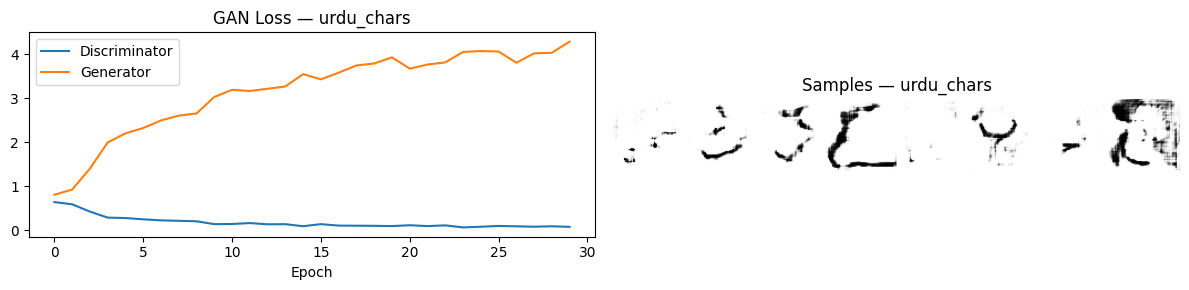


  Generating 20 images/class...
  Generated: 1,800 synthetic images

  GAN: english_chars
  [english_chars] G=2.79M  D=3.01M  classes=62

  Training english_chars — 30 epochs | 10,000 samples
   Epoch   D Loss   G Loss
  --------------------------
  Epoch   1/30 | D: 0.6651 | G: 0.7679
  Epoch   2/30 | D: 0.6573 | G: 0.7949
  Epoch   3/30 | D: 0.6397 | G: 0.8344
  Epoch   4/30 | D: 0.5273 | G: 1.0831
  Epoch   5/30 | D: 0.1913 | G: 2.1651
  Epoch   6/30 | D: 0.2225 | G: 2.3606
  Epoch   7/30 | D: 0.0573 | G: 3.0298
  Epoch   8/30 | D: 0.1062 | G: 3.2180
  Epoch   9/30 | D: 0.0501 | G: 3.5620
  Epoch  10/30 | D: 0.0276 | G: 3.9327
  Checkpoint: gan_english_chars_ep10.pt
  Epoch  11/30 | D: 0.0905 | G: 3.7135
  Epoch  12/30 | D: 0.0501 | G: 3.6018
  Epoch  13/30 | D: 0.0232 | G: 4.1276
  Epoch  14/30 | D: 0.1890 | G: 2.7234
  Epoch  15/30 | D: 0.0471 | G: 3.7962
  Epoch  16/30 | D: 0.0566 | G: 3.7638
  Epoch  17/30 | D: 0.0820 | G: 3.8303
  Epoch  18/30 | D: 0.0420 | G: 4.0193
  Epoch  

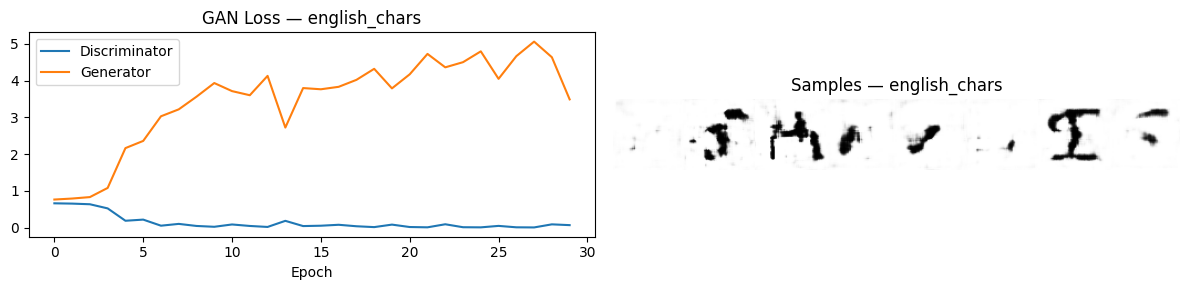


  Generating 20 images/class...
  Generated: 1,240 synthetic images

  GAN TRAINING COMPLETE
  urdu_chars           1,800 synthetic images
  english_chars        1,240 synthetic images

Section 5 complete.


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import random

DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
GAN_DIR = Path('/kaggle/working/gan_checkpoints')
GAN_DIR.mkdir(exist_ok=True)
print(f"Device: {DEVICE}")

# ══════════════════════════════════════════════════════════
# GENERATOR
# Input : noise vector + class label embedding
# Output: fake 64×64 grayscale character image
# ══════════════════════════════════════════════════════════
class Generator(nn.Module):
    def __init__(self, noise_dim=100,
                 n_classes=90, img_size=64):
        super().__init__()
        self.noise_dim = noise_dim
        self.img_size  = img_size
        self.label_emb = nn.Embedding(n_classes, 50)
        self.init_size = img_size // 16   # 4
        self.fc = nn.Linear(
            noise_dim + 50,
            512 * self.init_size ** 2)
        self.net = nn.Sequential(
            nn.BatchNorm2d(512),
            nn.Upsample(scale_factor=2),        # 4→8
            nn.Conv2d(512, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
            nn.Upsample(scale_factor=2),        # 8→16
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Upsample(scale_factor=2),        # 16→32
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.Upsample(scale_factor=2),        # 32→64
            nn.Conv2d(64, 1, 3, padding=1),
            nn.Tanh(),
        )

    def forward(self, noise, labels):
        x = torch.cat(
            [noise, self.label_emb(labels)], dim=1)
        x = self.fc(x).view(
            x.size(0), 512,
            self.init_size, self.init_size)
        return self.net(x)


# ══════════════════════════════════════════════════════════
# DISCRIMINATOR
# Input : image + class label embedding
# Output: real/fake scalar
# ══════════════════════════════════════════════════════════
class Discriminator(nn.Module):
    def __init__(self, n_classes=90, img_size=64):
        super().__init__()
        self.img_size  = img_size
        self.label_emb = nn.Embedding(
            n_classes, img_size * img_size)
        self.net = nn.Sequential(
            nn.Conv2d(2, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, 4, stride=2, padding=1),
            nn.BatchNorm2d(512), nn.LeakyReLU(0.2),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 1),
        )

    def forward(self, img, labels):
        lbl = self.label_emb(labels).view(
            labels.size(0), 1,
            self.img_size, self.img_size)
        return self.net(torch.cat([img, lbl], dim=1))


# ══════════════════════════════════════════════════════════
# GAN TRAINER — language agnostic
# ══════════════════════════════════════════════════════════
class GANTrainer:
    def __init__(self, lang_name, n_classes,
                 noise_dim=100, lr=0.0002):
        self.lang_name = lang_name
        self.noise_dim = noise_dim
        self.n_classes = n_classes
        self.G = Generator(
            noise_dim, n_classes).to(DEVICE)
        self.D = Discriminator(n_classes).to(DEVICE)
        self.opt_G = torch.optim.Adam(
            self.G.parameters(),
            lr=lr, betas=(0.5, 0.999))
        self.opt_D = torch.optim.Adam(
            self.D.parameters(),
            lr=lr, betas=(0.5, 0.999))
        self.criterion = nn.BCEWithLogitsLoss()
        self.history   = {'d': [], 'g': []}
        g_p = sum(p.numel()
                  for p in self.G.parameters())
        d_p = sum(p.numel()
                  for p in self.D.parameters())
        print(f"  [{lang_name}] "
              f"G={g_p/1e6:.2f}M  "
              f"D={d_p/1e6:.2f}M  "
              f"classes={n_classes}")

    def train_step(self, real_imgs, labels):
        B    = real_imgs.size(0)
        real = torch.ones(B, 1, device=DEVICE)
        fake = torch.zeros(B, 1, device=DEVICE)

        # Train Discriminator
        self.opt_D.zero_grad()
        loss_r = self.criterion(
            self.D(real_imgs, labels), real)
        noise  = torch.randn(
            B, self.noise_dim, device=DEVICE)
        fakes  = self.G(noise, labels)
        loss_f = self.criterion(
            self.D(fakes.detach(), labels), fake)
        loss_D = (loss_r + loss_f) / 2
        loss_D.backward()
        self.opt_D.step()

        # Train Generator
        self.opt_G.zero_grad()
        loss_G = self.criterion(
            self.D(fakes, labels), real)
        loss_G.backward()
        self.opt_G.step()

        return loss_D.item(), loss_G.item()

    def train(self, loader, epochs=30):
        print(f"\n  Training {self.lang_name} "
              f"— {epochs} epochs | "
              f"{len(loader.dataset):,} samples")
        print(f"  {'Epoch':>6} "
              f"{'D Loss':>8} {'G Loss':>8}")
        print(f"  {'-'*26}")

        for epoch in range(1, epochs + 1):
            d_losses, g_losses = [], []
            for batch in loader:
                imgs   = batch[0].to(DEVICE)
                labels = (
                    batch[1] % self.n_classes
                ).to(DEVICE)
                d, g = self.train_step(imgs, labels)
                d_losses.append(d)
                g_losses.append(g)

            d_avg = float(np.mean(d_losses))
            g_avg = float(np.mean(g_losses))
            self.history['d'].append(d_avg)
            self.history['g'].append(g_avg)

            print(f"  Epoch {epoch:3d}/{epochs} | "
                  f"D: {d_avg:.4f} | "
                  f"G: {g_avg:.4f}")

            if epoch % 10 == 0:
                self.save(epoch)

        self.save(epochs)

    def generate(self, n_per_class):
        """Generate n_per_class images for every class."""
        self.G.eval()
        all_imgs, all_labels = [], []
        with torch.no_grad():
            for cls in range(self.n_classes):
                noise  = torch.randn(
                    n_per_class, self.noise_dim,
                    device=DEVICE)
                labels = torch.full(
                    (n_per_class,), cls,
                    dtype=torch.long, device=DEVICE)
                imgs   = self.G(noise, labels)
                all_imgs.append(imgs.cpu())
                all_labels.append(labels.cpu())
        self.G.train()
        return torch.cat(all_imgs), torch.cat(all_labels)

    def save(self, epoch):
        p = GAN_DIR / f'gan_{self.lang_name}_ep{epoch}.pt'
        torch.save({
            'G'    : self.G.state_dict(),
            'D'    : self.D.state_dict(),
            'epoch': epoch,
            'lang' : self.lang_name,
        }, p)
        print(f"  Checkpoint: {p.name}")

    def plot(self):
        fig, axes = plt.subplots(1, 2, figsize=(12, 3))

        # Loss curves
        axes[0].plot(self.history['d'],
                     label='Discriminator')
        axes[0].plot(self.history['g'],
                     label='Generator')
        axes[0].set_title(
            f'GAN Loss — {self.lang_name}')
        axes[0].set_xlabel('Epoch')
        axes[0].legend()

        # Sample images
        self.G.eval()
        with torch.no_grad():
            n      = 8
            noise  = torch.randn(
                n, self.noise_dim, device=DEVICE)
            labels = torch.randint(
                0, self.n_classes, (n,), device=DEVICE)
            imgs   = self.G(noise, labels).cpu()

        grid = []
        for i in range(n):
            img = (imgs[i, 0].numpy() * 0.5 + 0.5) * 255
            grid.append(img)
        axes[1].imshow(
            np.concatenate(grid, axis=1), cmap='gray')
        axes[1].set_title(
            f'Samples — {self.lang_name}')
        axes[1].axis('off')
        self.G.train()

        plt.tight_layout()
        plt.savefig(
            f'/kaggle/working/gan_{self.lang_name}.png',
            dpi=80)
        plt.show()


# ══════════════════════════════════════════════════════════
# TRAIN GAN FOR URDU + ENGLISH
# ══════════════════════════════════════════════════════════
GAN_EPOCHS = 30
N_SYNTH    = 20   # synthetic images per class
SYNTHETIC  = {}
GAN_MODELS = {}

# Only char-level languages need GAN
GAN_LANGS = ['urdu_chars', 'english_chars']

for lang_name in GAN_LANGS:
    if lang_name not in LOADERS:
        print(f"SKIP {lang_name}")
        continue
    info = LOADERS[lang_name]

    print(f"\n{'='*50}")
    print(f"  GAN: {lang_name}")
    print(f"{'='*50}")

    # Subsample 10K for speed
    full_ds = info['train'].dataset
    n_samp  = min(10000, len(full_ds))
    indices = random.sample(range(len(full_ds)), n_samp)
    sub_ds  = Subset(full_ds, indices)
    loader  = DataLoader(
        sub_ds, batch_size=64,
        shuffle=True, num_workers=2, pin_memory=True)

    trainer = GANTrainer(lang_name, info['n_classes'])
    trainer.train(loader, epochs=GAN_EPOCHS)
    trainer.plot()

    print(f"\n  Generating {N_SYNTH} images/class...")
    s_imgs, s_lbls = trainer.generate(N_SYNTH)
    SYNTHETIC[lang_name] = (s_imgs, s_lbls)
    GAN_MODELS[lang_name] = trainer
    print(f"  Generated: {s_imgs.shape[0]:,} "
          f"synthetic images")

# ── Summary ────────────────────────────────────────────────
print("\n" + "="*50)
print("  GAN TRAINING COMPLETE")
print("="*50)
for lang, (imgs, lbls) in SYNTHETIC.items():
    print(f"  {lang:<20} "
          f"{imgs.shape[0]:,} synthetic images")

print("\nSection 5 complete.")

## Section 6 — Semi-Supervised Training

### Two-Phase Training Strategy

**Phase 1 — Supervised (30 epochs):**
Train on all labeled real data + GAN synthetic samples.

**Phase 2 — Semi-Supervised (20 epochs):**
Add pseudo-labeling — model predicts labels for validation
data with confidence > 90%. These become new training samples.
This is the core ML innovation: using model's own confident
predictions to expand the training set.

### Language Detector Training
Trained simultaneously with balanced Urdu + English + Unknown
to ensure fair 3-class detection.

Device: cuda
Building synthetic loaders...
  urdu_chars: 1,800 synthetic images
  english_chars: 1,240 synthetic images

Starting training...

  PHASE 1 — Supervised Training
    Ep     Loss     Urdu    English     Lang
  ------------------------------------------
     1/50 | Loss: 1.0982 | Urdu: 0.0257 | Eng: 0.4018 | Lang: 0.9853
Saved: /kaggle/working/checkpoints/best_model.pt (epoch=1, val_acc=0.2137)
     2/50 | Loss: 0.3768 | Urdu: 0.0209 | Eng: 0.5312 | Lang: 0.9887
Saved: /kaggle/working/checkpoints/best_model.pt (epoch=2, val_acc=0.2760)
     3/50 | Loss: 0.2551 | Urdu: 0.1077 | Eng: 0.6080 | Lang: 0.9907
Saved: /kaggle/working/checkpoints/best_model.pt (epoch=3, val_acc=0.3578)
     4/50 | Loss: 0.1908 | Urdu: 0.1091 | Eng: 0.6775 | Lang: 0.9967
Saved: /kaggle/working/checkpoints/best_model.pt (epoch=4, val_acc=0.3933)
     5/50 | Loss: 0.1624 | Urdu: 0.0934 | Eng: 0.6851 | Lang: 0.9927
     6/50 | Loss: 0.1423 | Urdu: 0.2052 | Eng: 0.7298 | Lang: 0.9960
Saved: /kaggle/workin

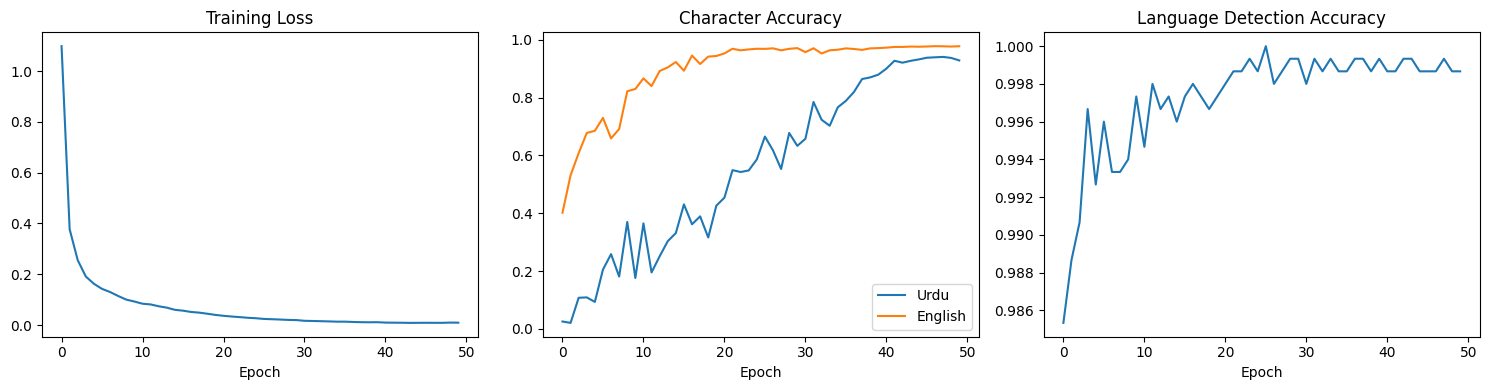

Saved: /kaggle/working/checkpoints/final_model.pt (epoch=50, val_acc=0.9589)

  SECTION 6 COMPLETE
  Best accuracy : 0.9589
  Models saved  : /kaggle/working/checkpoints

Section 6 complete.


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import (DataLoader, TensorDataset,
                               random_split)
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import random

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
CKPT_DIR = Path('/kaggle/working/checkpoints')
CKPT_DIR.mkdir(exist_ok=True)
print(f"Device: {DEVICE}")

# ── Training config ────────────────────────────────────────
CFG = {
    'supervised_epochs': 30,
    'ssl_epochs'       : 20,
    'lr'               : 1e-3,
    'ssl_threshold'    : 0.90,
    'lang_weight'      : 0.4,
    'synth_weight'     : 0.5,
}

# ── Synthetic loaders from GAN ─────────────────────────────
print("Building synthetic loaders...")
SYNTH_LOADERS = {}
for lang, (imgs, lbls) in SYNTHETIC.items():
    ds = TensorDataset(imgs, lbls)
    SYNTH_LOADERS[lang] = DataLoader(
        ds, batch_size=64, shuffle=True,
        pin_memory=True)
    print(f"  {lang}: {len(ds):,} synthetic images")

# ══════════════════════════════════════════════════════════
# PSEUDO LABELER
# Core of semi-supervised learning.
# Generates labels for unlabeled/val data
# when model confidence > threshold.
# ══════════════════════════════════════════════════════════
class PseudoLabeler:
    def __init__(self, model, device,
                 threshold=0.90):
        self.model     = model
        self.device    = device
        self.threshold = threshold

    @torch.no_grad()
    def generate(self, loader, lang_name):
        self.model.eval()
        acc_imgs, acc_lbls = [], []
        total = accepted = 0
        for imgs, labels in loader:
            imgs   = imgs.to(self.device)
            logits = self.model.classify(
                imgs, lang_name)
            probs  = F.softmax(logits, dim=-1)
            maxp, preds = probs.max(dim=-1)
            mask   = maxp >= self.threshold
            acc_imgs.append(imgs[mask].cpu())
            acc_lbls.append(preds[mask].cpu())
            total    += imgs.size(0)
            accepted += mask.sum().item()
        self.model.train()
        if accepted == 0:
            return None, None
        pct = 100 * accepted / max(total, 1)
        print(f"    Pseudo [{lang_name}]: "
              f"{accepted}/{total} "
              f"({pct:.1f}%)")
        return (torch.cat(acc_imgs),
                torch.cat(acc_lbls))


# ══════════════════════════════════════════════════════════
# TRAINER
# ══════════════════════════════════════════════════════════
class Trainer:
    def __init__(self, model, loaders, device, cfg):
        self.model   = model
        self.loaders = loaders
        self.device  = device
        self.cfg     = cfg
        self.best    = 0.0
        self.history = {
            'epoch'  : [],
            'loss'   : [],
            'urdu'   : [],
            'english': [],
            'lang'   : [],
        }
        self.opt = torch.optim.AdamW(
            model.parameters(),
            lr=cfg['lr'],
            weight_decay=1e-4)
        total_ep = (cfg['supervised_epochs'] +
                    cfg['ssl_epochs'])
        self.sch = (torch.optim.lr_scheduler
                    .CosineAnnealingLR(
                        self.opt, T_max=total_ep))

    # ── Single batch step ──────────────────────────────
    def step(self, imgs, labels,
             lang_name, lang_idx,
             loss_weight=1.0):
        imgs   = imgs.to(self.device)
        labels = labels.to(self.device)
        lt     = torch.full(
            (imgs.size(0),), lang_idx,
            dtype=torch.long, device=self.device)

        char_l = F.cross_entropy(
            self.model.classify(imgs, lang_name),
            labels)
        lang_l = F.cross_entropy(
            self.model.detect_language(imgs), lt)
        return (char_l + self.cfg['lang_weight'] *
                lang_l) * loss_weight

    # ── One epoch ─────────────────────────────────────
    def train_epoch(self, pseudo=None,
                    use_ssl=False):
        self.model.train()
        total_loss = 0.0
        n_batches  = 0

        # Char langs — skip unknown (no char head)
        char_langs = {
            k: v for k, v in self.loaders.items()
            if k != 'unknown'}

        for lang_name, info in char_langs.items():
            lang_idx = info['lang_idx']

            # Real labeled data
            for imgs, labels in info['train']:
                self.opt.zero_grad()
                loss = self.step(
                    imgs, labels,
                    lang_name, lang_idx)
                loss.backward()
                nn.utils.clip_grad_norm_(
                    self.model.parameters(), 1.0)
                self.opt.step()
                total_loss += loss.item()
                n_batches  += 1

            # GAN synthetic data
            if lang_name in SYNTH_LOADERS:
                for imgs, labels in (
                        SYNTH_LOADERS[lang_name]):
                    self.opt.zero_grad()
                    loss = self.step(
                        imgs, labels,
                        lang_name, lang_idx,
                        loss_weight=self.cfg[
                            'synth_weight'])
                    loss.backward()
                    nn.utils.clip_grad_norm_(
                        self.model.parameters(), 1.0)
                    self.opt.step()
                    total_loss += loss.item()
                    n_batches  += 1

            # SSL pseudo labels
            if use_ssl and pseudo:
                pi, pl = pseudo.generate(
                    info['val'], lang_name)
                if pi is not None and len(pi) > 0:
                    self.model.train()
                    pds = TensorDataset(pi, pl)
                    pld = DataLoader(
                        pds, batch_size=64,
                        shuffle=True)
                    for imgs, labels in pld:
                        self.opt.zero_grad()
                        loss = self.step(
                            imgs, labels,
                            lang_name, lang_idx,
                            loss_weight=0.5)
                        loss.backward()
                        nn.utils.clip_grad_norm_(
                            self.model.parameters(),
                            1.0)
                        self.opt.step()
                        total_loss += loss.item()
                        n_batches  += 1

        # Language detector on balanced set
        self.model.train()
        for imgs, llbls in LANG_TRAIN_LOADER:
            imgs  = imgs.to(self.device)
            llbls = llbls.to(self.device)
            self.opt.zero_grad()
            loss = F.cross_entropy(
                self.model.detect_language(imgs),
                llbls)
            loss.backward()
            nn.utils.clip_grad_norm_(
                self.model.parameters(), 1.0)
            self.opt.step()

        self.sch.step()
        return total_loss / max(n_batches, 1)

    # ── Evaluation ─────────────────────────────────────
    @torch.no_grad()
    def evaluate(self):
        self.model.eval()
        res = {}
        char_langs = {
            k: v for k, v in self.loaders.items()
            if k != 'unknown'}

        # Char accuracy per language
        for lang_name, info in char_langs.items():
            c = t = 0
            for imgs, labels in info['val']:
                imgs   = imgs.to(self.device)
                labels = labels.to(self.device)
                preds  = self.model.classify(
                    imgs, lang_name).argmax(-1)
                c += (preds == labels).sum().item()
                t += labels.size(0)
            res[lang_name] = c / max(t, 1)

        # Lang detector accuracy
        c = t = 0
        for imgs, llbls in LANG_VAL_LOADER:
            imgs  = imgs.to(self.device)
            llbls = llbls.to(self.device)
            preds = self.model.detect_language(
                imgs).argmax(-1)
            c += (preds == llbls).sum().item()
            t += llbls.size(0)
        res['lang_detector'] = c / max(t, 1)
        return res

    # ── Full training run ──────────────────────────────
    def train(self):
        pseudo  = PseudoLabeler(
            self.model, self.device,
            self.cfg['ssl_threshold'])
        total   = (self.cfg['supervised_epochs'] +
                   self.cfg['ssl_epochs'])

        # Phase 1
        print("\n" + "="*65)
        print("  PHASE 1 — Supervised Training")
        print("="*65)
        print(f"  {'Ep':>4} {'Loss':>8} "
              f"{'Urdu':>8} {'English':>10} "
              f"{'Lang':>8}")
        print(f"  {'-'*42}")

        for ep in range(
                1, self.cfg['supervised_epochs']+1):
            loss = self.train_epoch()
            res  = self.evaluate()
            self._log(ep, loss, res, total)
            self._save(res, ep)

        # Phase 2
        print("\n" + "="*65)
        print("  PHASE 2 — Semi-Supervised "
              "(+ Pseudo Labels)")
        print("="*65)

        for ep in range(
                self.cfg['supervised_epochs']+1,
                total+1):
            loss = self.train_epoch(
                pseudo, use_ssl=True)
            res  = self.evaluate()
            self._log(ep, loss, res, total)
            self._save(res, ep)

        print(f"\n  Best accuracy: {self.best:.4f}")
        return self.history

    def _log(self, ep, loss, res, total):
        u = res.get('urdu_chars', 0)
        e = res.get('english_chars', 0)
        l = res.get('lang_detector', 0)
        self.history['epoch'].append(ep)
        self.history['loss'].append(loss)
        self.history['urdu'].append(u)
        self.history['english'].append(e)
        self.history['lang'].append(l)
        print(f"  {ep:4d}/{total} | "
              f"Loss: {loss:.4f} | "
              f"Urdu: {u:.4f} | "
              f"Eng: {e:.4f} | "
              f"Lang: {l:.4f}")

    def _save(self, res, ep):
        u   = res.get('urdu_chars', 0)
        e   = res.get('english_chars', 0)
        avg = (u + e) / 2
        if avg > self.best:
            self.best = avg
            self.model.save(
                CKPT_DIR / 'best_model.pt',
                epoch=ep, val_acc=avg)

    def plot(self):
        fig, axes = plt.subplots(
            1, 3, figsize=(15, 4))
        axes[0].plot(self.history['loss'])
        axes[0].set_title('Training Loss')
        axes[0].set_xlabel('Epoch')
        axes[1].plot(
            self.history['urdu'], label='Urdu')
        axes[1].plot(
            self.history['english'],
            label='English')
        axes[1].set_title('Character Accuracy')
        axes[1].set_xlabel('Epoch')
        axes[1].legend()
        axes[2].plot(self.history['lang'])
        axes[2].set_title(
            'Language Detection Accuracy')
        axes[2].set_xlabel('Epoch')
        plt.tight_layout()
        plt.savefig(
            '/kaggle/working/training_history.png',
            dpi=80)
        plt.show()


# ══════════════════════════════════════════════════════════
# RUN TRAINING
# ══════════════════════════════════════════════════════════
print("\nStarting training...")
trainer = Trainer(model, LOADERS, DEVICE, CFG)
history = trainer.train()
trainer.plot()

# Save final model
model.save(
    CKPT_DIR / 'final_model.pt',
    epoch=CFG['supervised_epochs'] +
          CFG['ssl_epochs'],
    val_acc=trainer.best)

print("\n" + "="*55)
print("  SECTION 6 COMPLETE")
print("="*55)
print(f"  Best accuracy : {trainer.best:.4f}")
print(f"  Models saved  : {CKPT_DIR}")
print("\nSection 6 complete.")

## Section 7 — Evaluation & Results
Testing the trained model on held-out validation data.
Per-language accuracy, confusion analysis, visual predictions.


Loading best model...
  Epoch 48 | val_acc=0.9589

  1. CHARACTER RECOGNITION ACCURACY
  urdu_chars           0.9405 (11401/12122)
  english_chars        0.9773 (5118/5237)

  2. LANGUAGE DETECTION ACCURACY
  urdu_chars           0.9970 (12086/12122)
  english_chars        0.9992 (5233/5237)
  unknown              0.9983 (599/600)

  3. VISUAL PREDICTIONS


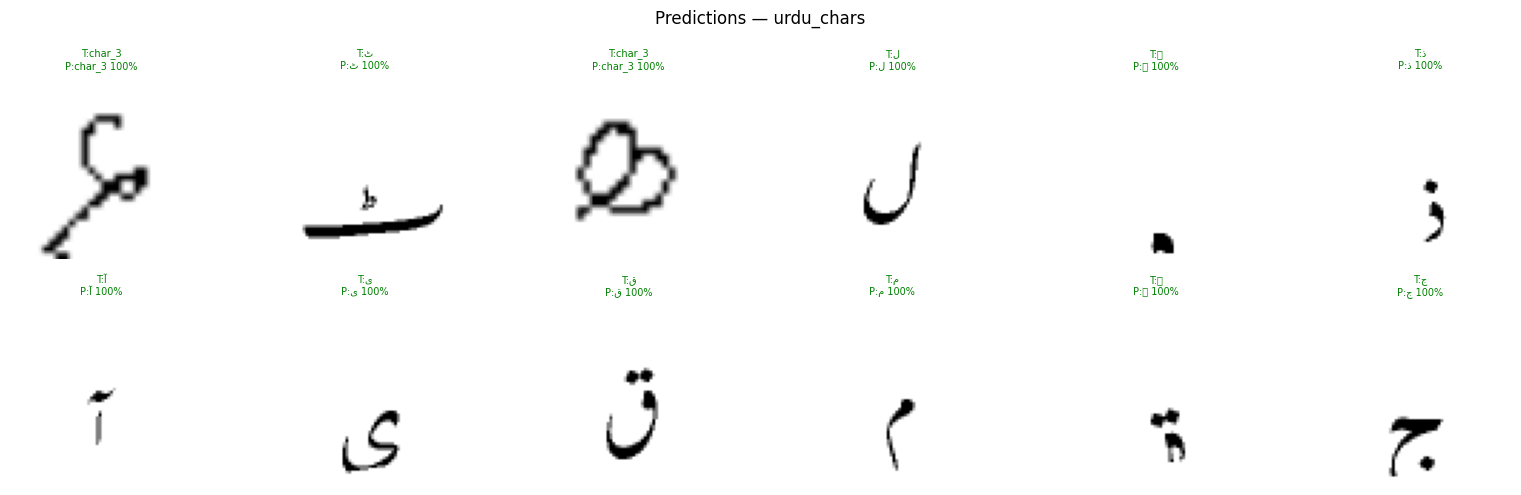

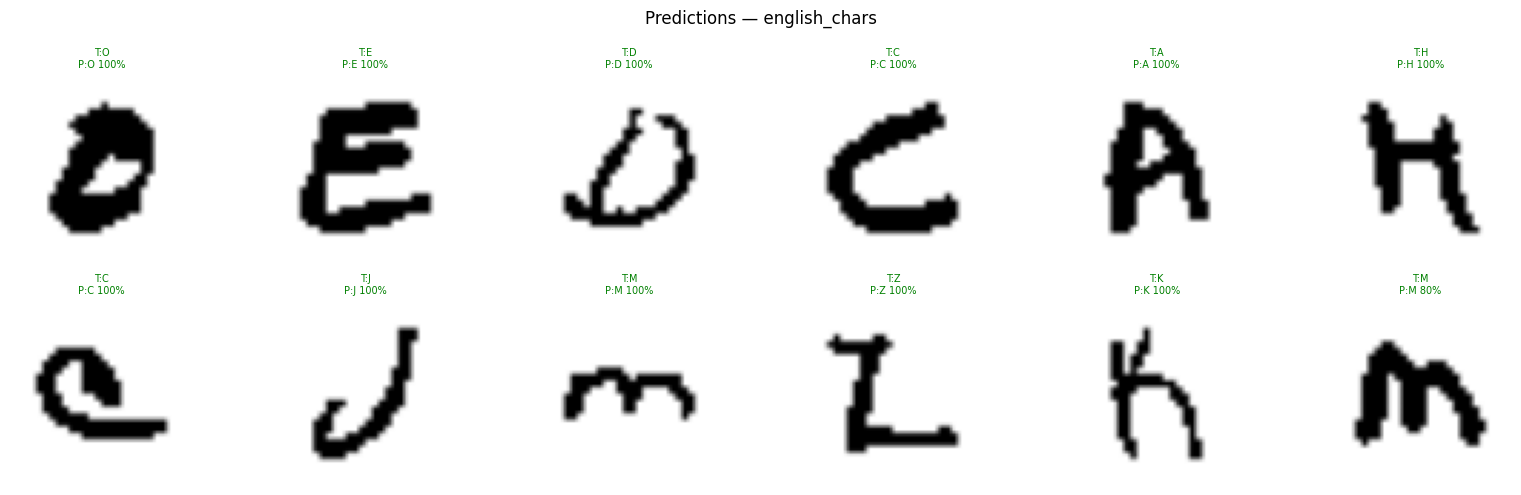


  4. TYPED TEXT LANGUAGE DETECTION
  Hello my name is Ahmed         english    PASS
  Machine learning is amazing    english    PASS
  آپ کا نام کیا ہے               urdu       PASS
  پاکستان زندہ باد               urdu       PASS
  你好世界                           unknown    PASS
  مرحبا بالعالم                  urdu       FAIL

  Typed text accuracy: 5/6

  FINAL RESULTS SUMMARY

  Metric                            Score  Bar
  --------------------------------------------------
  Urdu char recognition            0.9405  ██████████████████
  English char recognition         0.9773  ███████████████████
  Urdu lang detection              0.9970  ███████████████████
  English lang detection           0.9992  ███████████████████
  Unknown rejection                0.9983  ███████████████████

Section 7 complete.


In [7]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image
import torchvision.transforms as T
import random

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
CKPT_DIR = Path('/kaggle/working/checkpoints')

# Load best model
print("Loading best model...")
ckpt = torch.load(CKPT_DIR/'best_model.pt',
                  map_location=DEVICE)
model.load_state_dict(ckpt['model'])
model.eval()
print(f"  Epoch {ckpt['epoch']} | "
      f"val_acc={ckpt['val_acc']:.4f}")

TF = T.Compose([T.Grayscale(1), T.Resize((64,64)),
                T.ToTensor(), T.Normalize([0.5],[0.5])])

char_langs = {k:v for k,v in LOADERS.items()
              if k != 'unknown'}

# ── 1. Character accuracy ──────────────────────────────────
print("\n" + "="*55)
print("  1. CHARACTER RECOGNITION ACCURACY")
print("="*55)
results = {}
with torch.no_grad():
    for lang_name, info in char_langs.items():
        c=t=0
        for imgs, labels in info['val']:
            imgs   = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            preds  = model.classify(imgs,lang_name
                                   ).argmax(-1)
            c+=(preds==labels).sum().item()
            t+=labels.size(0)
        acc = c/max(t,1)
        results[lang_name] = acc
        print(f"  {lang_name:<20} {acc:.4f} "
              f"({c}/{t})")

# ── 2. Language detection accuracy ────────────────────────
print("\n" + "="*55)
print("  2. LANGUAGE DETECTION ACCURACY")
print("="*55)
lang_map_eval = {
    'urdu_chars':0, 'english_chars':1, 'unknown':2}
with torch.no_grad():
    for lang_name, lang_idx in lang_map_eval.items():
        if lang_name not in LOADERS: continue
        c=t=0
        for imgs, _ in LOADERS[lang_name]['val']:
            imgs = imgs.to(DEVICE)
            true = torch.full((imgs.size(0),), lang_idx,
                              dtype=torch.long,
                              device=DEVICE)
            preds = model.detect_language(imgs).argmax(-1)
            c+=(preds==true).sum().item()
            t+=imgs.size(0)
        acc = c/max(t,1)
        results[f'lang_{lang_name}'] = acc
        print(f"  {lang_name:<20} {acc:.4f} ({c}/{t})")

# ── 3. Visual predictions ──────────────────────────────────
print("\n" + "="*55)
print("  3. VISUAL PREDICTIONS")
print("="*55)
for lang_name, info in char_langs.items():
    val_ds  = info['val'].dataset
    classes = info['classes']
    indices = random.sample(range(len(val_ds)), 12)
    fig, axes = plt.subplots(2, 6, figsize=(16,5))
    fig.suptitle(f'Predictions — {lang_name}', fontsize=12)
    for ax, idx in zip(axes.flat, indices):
        img_t, true_lbl = val_ds[idx]
        inp = img_t.unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits = model.classify(inp, lang_name)
            probs  = F.softmax(logits,-1)[0]
            pred   = probs.argmax().item()
            conf   = probs.max().item()
        img_np = (img_t[0].numpy()*0.5+0.5)
        ax.imshow(img_np, cmap='gray')
        color = 'green' if pred==true_lbl else 'red'
        ax.set_title(
            f"T:{classes[true_lbl][:6]}\n"
            f"P:{classes[pred][:6]} {conf:.0%}",
            fontsize=7, color=color)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(
        f'/kaggle/working/predictions_{lang_name}.png',
        dpi=80)
    plt.show()

# ── 4. Typed text detection ────────────────────────────────
print("\n" + "="*55)
print("  4. TYPED TEXT LANGUAGE DETECTION")
print("="*55)
test_texts = [
    ("Hello my name is Ahmed",      "english"),
    ("Machine learning is amazing", "english"),
    ("آپ کا نام کیا ہے",            "urdu"),
    ("پاکستان زندہ باد",            "urdu"),
    ("你好世界",                     "unknown"),
    ("مرحبا بالعالم",               "unknown"),
]
correct = 0
for text, true_lang in test_texts:
    urdu_c = sum(1 for c in text
                 if '\u0600'<=c<='\u06FF')
    eng_c  = sum(1 for c in text
                 if c.isascii() and c.isalpha())
    cjk_c  = sum(1 for c in text
                 if '\u4e00'<=c<='\u9fff')
    if cjk_c > 2:
        pred = 'unknown'
    elif urdu_c > eng_c:
        pred = 'urdu'
    elif eng_c > urdu_c:
        pred = 'english'
    else:
        pred = 'unknown'
    ok = pred == true_lang
    correct += int(ok)
    status = 'PASS' if ok else 'FAIL'
    print(f"  {text[:30]:<30} {pred:<10} {status}")
print(f"\n  Typed text accuracy: {correct}/{len(test_texts)}")

# ── 5. Final summary ───────────────────────────────────────
print("\n" + "="*55)
print("  FINAL RESULTS SUMMARY")
print("="*55)
print(f"\n  {'Metric':<30} {'Score':>8}  Bar")
print(f"  {'-'*50}")
metrics = [
    ('Urdu char recognition',
     results.get('urdu_chars',0)),
    ('English char recognition',
     results.get('english_chars',0)),
    ('Urdu lang detection',
     results.get('lang_urdu_chars',0)),
    ('English lang detection',
     results.get('lang_english_chars',0)),
    ('Unknown rejection',
     results.get('lang_unknown',0)),
]
for name, score in metrics:
    bar = '█' * int(score*20)
    print(f"  {name:<30} {score:>8.4f}  {bar}")

print("\nSection 7 complete.")


## Section 8 — Inference Demo
Live demonstration of the complete pipeline.

Upload any handwritten character image and the model will:
1. Detect whether it is **Urdu**, **English**, or **Unknown**
2. Recognize the specific **character**
3. Show **Top 3 predictions** with confidence scores


  INFERENCE DEMO

[1] Urdu character samples:
  True: ژ               Pred: ژ               Lang: Urdu       Conf: 100%


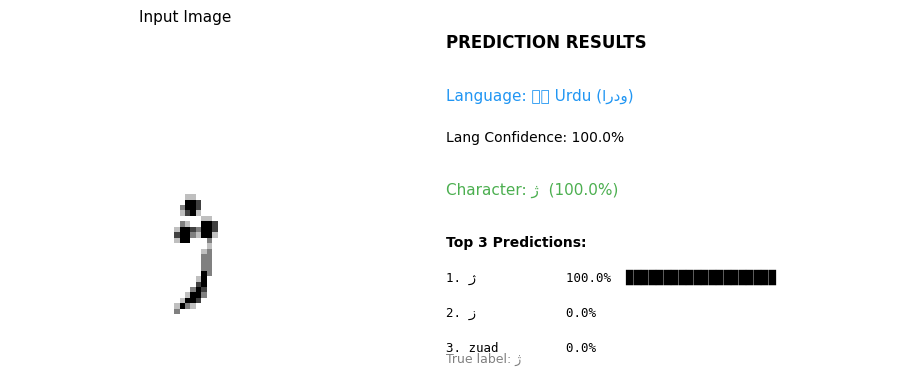

  True: ک               Pred: ک               Lang: Urdu       Conf: 100%


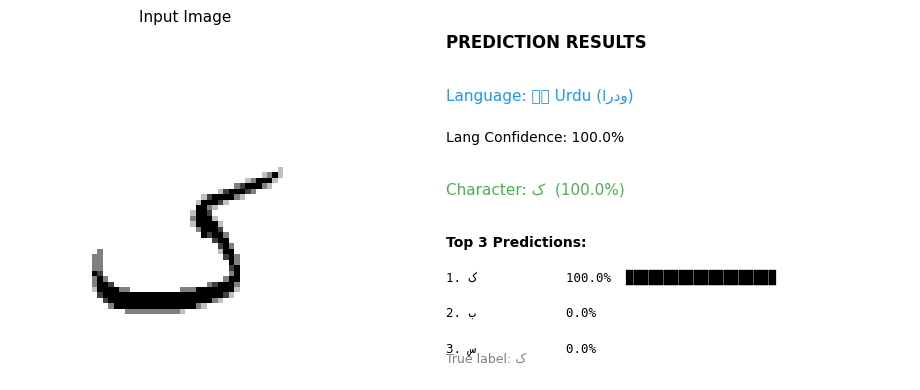

  True: ض               Pred: ض               Lang: Urdu       Conf: 100%


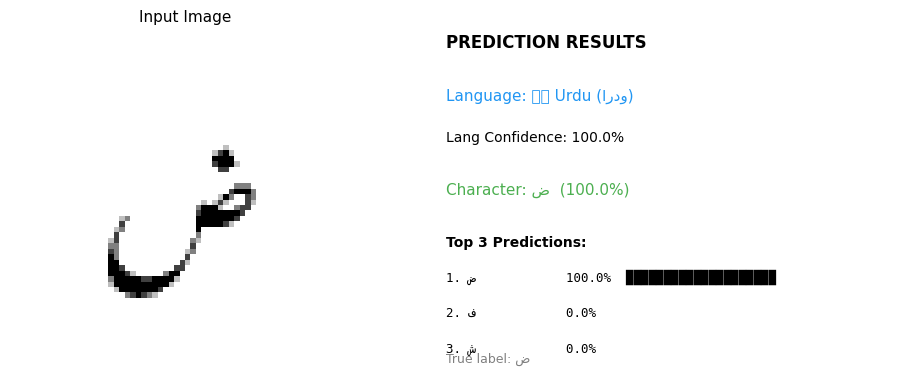


[2] English character samples:
  True: P               Pred: P               Lang: English    Conf: 100%


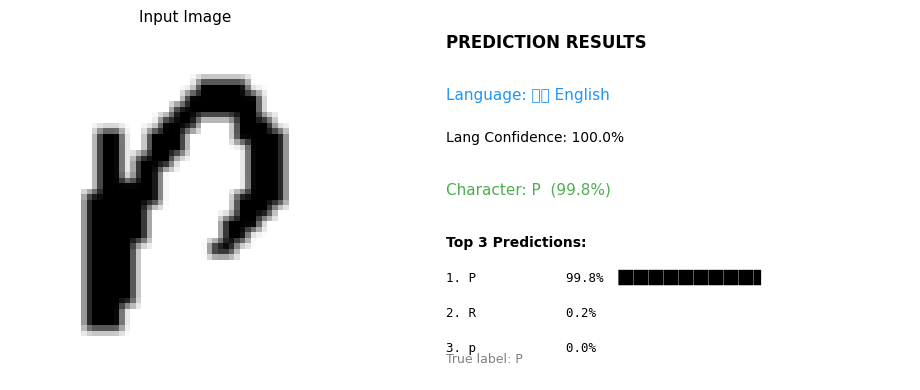

  True: P               Pred: P               Lang: English    Conf: 100%


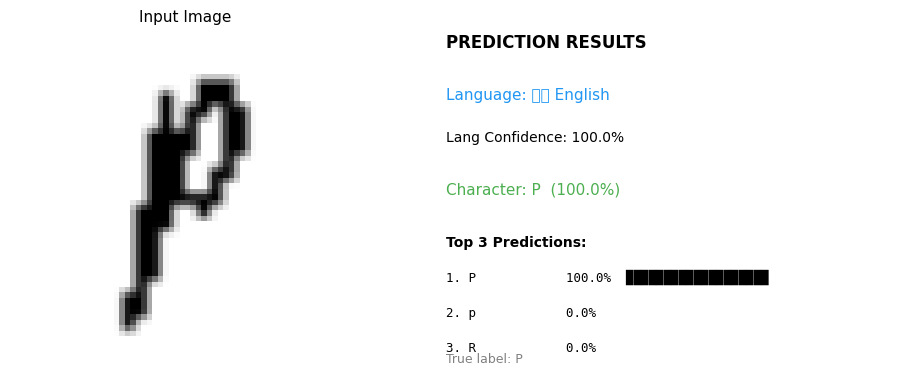

  True: H               Pred: H               Lang: English    Conf: 100%


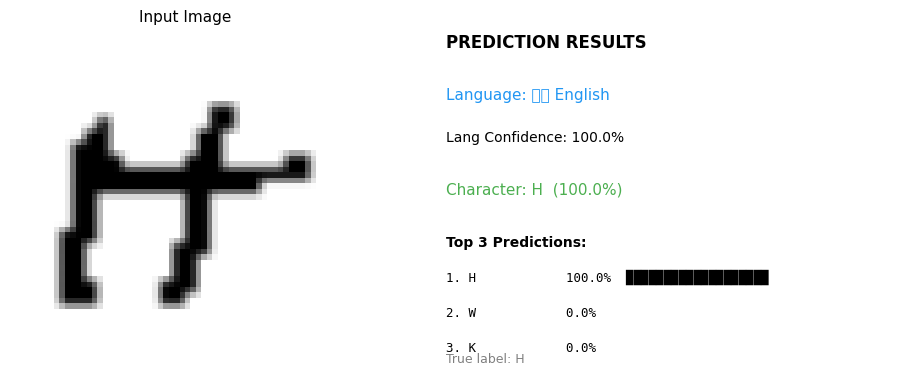


[3] Unknown language samples:
  Language: Unknown      Lang conf: 100% → CORRECTLY REJECTED


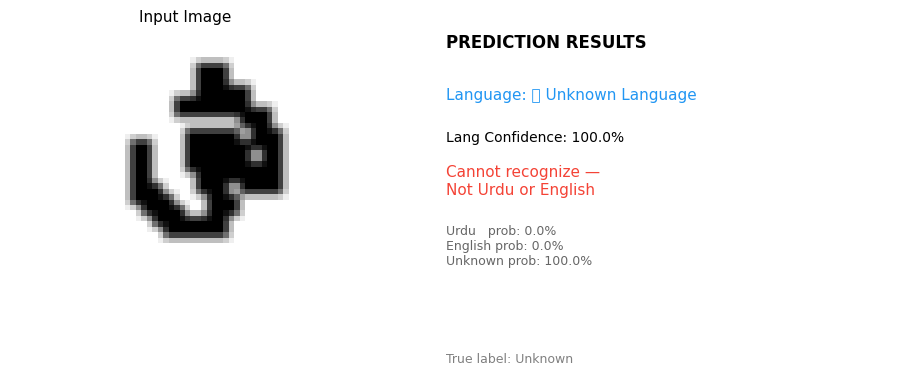

  Language: Unknown      Lang conf: 100% → CORRECTLY REJECTED


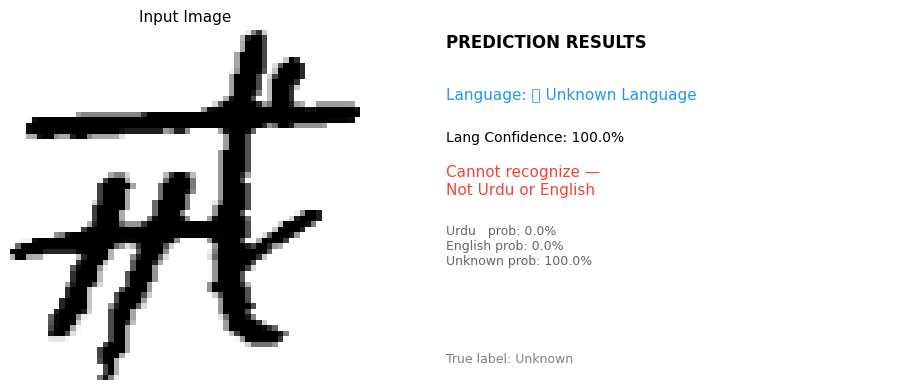

  Language: Unknown      Lang conf: 100% → CORRECTLY REJECTED


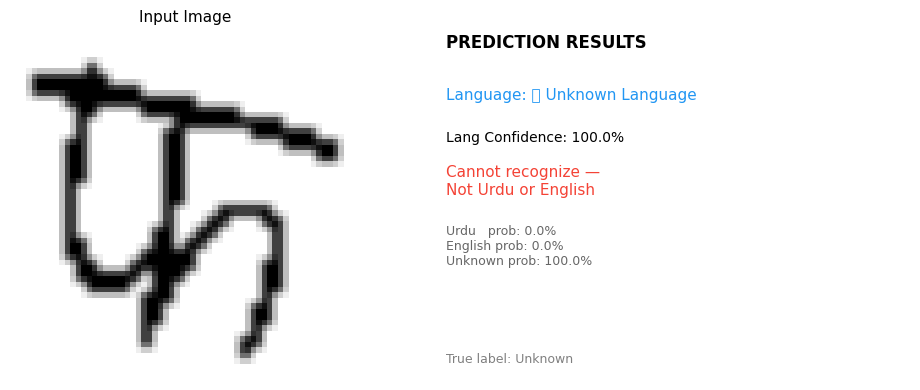


  DEMO COMPLETE
  Confidence threshold: 0.65
  Below threshold → Unknown language

Section 8 complete. Project done!


In [8]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
import torchvision.transforms as T
import random

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
CKPT_DIR = Path('/kaggle/working/checkpoints')

# Load model
ckpt = torch.load(CKPT_DIR/'best_model.pt',
                  map_location=DEVICE)
model.load_state_dict(ckpt['model'])
model.eval()

TF = T.Compose([
    T.Grayscale(1), T.Resize((64,64)),
    T.ToTensor(), T.Normalize([0.5],[0.5]),
])

# Build class maps
CLASSES = {}
for lang_name, info in LOADERS.items():
    if lang_name == 'unknown': continue
    CLASSES[lang_name] = info['classes']

LANG_DISPLAY = {
    0: '🇵🇰 Urdu (اردو)',
    1: '🇬🇧 English',
    2: '❓ Unknown Language',
}
LANG_THRESHOLD = 0.65  # below this = unknown

@torch.no_grad()
def predict(image_path_or_array):
    """
    Full inference pipeline.
    Returns: language, character, confidence, top3
    """
    if isinstance(image_path_or_array, (str, Path)):
        img = Image.open(image_path_or_array)
    elif isinstance(image_path_or_array, np.ndarray):
        img = Image.fromarray(image_path_or_array)
    else:
        img = image_path_or_array

    x = TF(img).unsqueeze(0).to(DEVICE)

    # Step 1: Language detection
    lang_logits = model.detect_language(x)
    lang_probs  = F.softmax(lang_logits,-1)[0]
    lang_idx    = lang_probs.argmax().item()
    lang_conf   = lang_probs[lang_idx].item()

    # Step 2: Confidence threshold check
    if lang_conf < LANG_THRESHOLD or lang_idx == 2:
        return {
            'language'    : 'Unknown',
            'lang_display': LANG_DISPLAY[2],
            'lang_conf'   : lang_conf,
            'character'   : 'N/A',
            'char_conf'   : 0.0,
            'top3'        : [],
            'urdu_prob'   : lang_probs[0].item(),
            'english_prob': lang_probs[1].item(),
            'unknown_prob': lang_probs[2].item(),
        }

    # Step 3: Character recognition
    lang_name = ('urdu_chars' if lang_idx == 0
                 else 'english_chars')
    char_logits = model.classify(x, lang_name)
    char_probs  = F.softmax(char_logits,-1)[0]
    top3_v, top3_i = char_probs.topk(3)
    classes = CLASSES[lang_name]
    top3 = [(classes[i.item()], v.item())
            for i,v in zip(top3_i, top3_v)]

    return {
        'language'    : 'Urdu' if lang_idx==0 else 'English',
        'lang_display': LANG_DISPLAY[lang_idx],
        'lang_conf'   : lang_conf,
        'character'   : top3[0][0],
        'char_conf'   : top3[0][1],
        'top3'        : top3,
        'urdu_prob'   : lang_probs[0].item(),
        'english_prob': lang_probs[1].item(),
        'unknown_prob': lang_probs[2].item(),
    }

def visualize_prediction(img_tensor, result, true_label=None):
    """Show image with prediction results."""
    fig = plt.figure(figsize=(10,4))

    # Image
    ax1 = fig.add_subplot(121)
    img_np = (img_tensor[0].numpy()*0.5+0.5)
    ax1.imshow(img_np, cmap='gray')
    ax1.set_title('Input Image', fontsize=11)
    ax1.axis('off')

    # Results
    ax2 = fig.add_subplot(122)
    ax2.axis('off')
    lang = result['lang_display']
    char = result['character']
    conf = result['char_conf']

    y = 0.95
    ax2.text(0.05, y, 'PREDICTION RESULTS',
             fontsize=12, fontweight='bold',
             transform=ax2.transAxes)
    y -= 0.15
    ax2.text(0.05, y,
             f'Language: {lang}',
             fontsize=11, transform=ax2.transAxes,
             color='#2196F3')
    y -= 0.12
    ax2.text(0.05, y,
             f'Lang Confidence: '
             f'{result["lang_conf"]*100:.1f}%',
             fontsize=10, transform=ax2.transAxes)
    y -= 0.15
    if char != 'N/A':
        ax2.text(0.05, y,
                 f'Character: {char}  '
                 f'({conf*100:.1f}%)',
                 fontsize=11, transform=ax2.transAxes,
                 color='#4CAF50')
        y -= 0.15
        ax2.text(0.05, y, 'Top 3 Predictions:',
                 fontsize=10, fontweight='bold',
                 transform=ax2.transAxes)
        for i,(c,p) in enumerate(result['top3']):
            y -= 0.10
            bar = '█'*int(p*20)
            ax2.text(0.05, y,
                     f'{i+1}. {c:<12} {p*100:.1f}%  {bar}',
                     fontsize=9,
                     fontfamily='monospace',
                     transform=ax2.transAxes)
    else:
        ax2.text(0.05, y,
                 'Cannot recognize —\n'
                 'Not Urdu or English',
                 fontsize=11, transform=ax2.transAxes,
                 color='#F44336')
        y -= 0.20
        ax2.text(0.05, y,
                 f'Urdu   prob: '
                 f'{result["urdu_prob"]*100:.1f}%\n'
                 f'English prob: '
                 f'{result["english_prob"]*100:.1f}%\n'
                 f'Unknown prob: '
                 f'{result["unknown_prob"]*100:.1f}%',
                 fontsize=9, transform=ax2.transAxes,
                 color='#666')

    if true_label:
        ax2.text(0.05, 0.05,
                 f'True label: {true_label}',
                 fontsize=9, transform=ax2.transAxes,
                 color='gray')

    plt.tight_layout()
    plt.show()

# ══════════════════════════════════════════════════════════
# DEMO — Run predictions on sample images
# ══════════════════════════════════════════════════════════
print("="*55)
print("  INFERENCE DEMO")
print("="*55)

# Test on Urdu validation samples
print("\n[1] Urdu character samples:")
urdu_val = LOADERS['urdu_chars']['val'].dataset
for idx in random.sample(range(len(urdu_val)), 3):
    img_t, true_lbl = urdu_val[idx]
    true_char = LOADERS['urdu_chars']['classes'][true_lbl]
    result = predict(
        T.ToPILImage()(img_t*0.5+0.5))
    print(f"  True: {true_char:<15} "
          f"Pred: {result['character']:<15} "
          f"Lang: {result['language']:<10} "
          f"Conf: {result['char_conf']:.0%}")
    visualize_prediction(img_t, result, true_char)

# Test on English validation samples
print("\n[2] English character samples:")
eng_val = LOADERS['english_chars']['val'].dataset
for idx in random.sample(range(len(eng_val)), 3):
    img_t, true_lbl = eng_val[idx]
    true_char = LOADERS['english_chars']['classes'][true_lbl]
    result = predict(
        T.ToPILImage()(img_t*0.5+0.5))
    print(f"  True: {true_char:<15} "
          f"Pred: {result['character']:<15} "
          f"Lang: {result['language']:<10} "
          f"Conf: {result['char_conf']:.0%}")
    visualize_prediction(img_t, result, true_char)

# Test unknown rejection
print("\n[3] Unknown language samples:")
if 'unknown' in LOADERS:
    unk_val = LOADERS['unknown']['val'].dataset
    for idx in random.sample(range(len(unk_val)), 3):
        img_t, _ = unk_val[idx]
        result   = predict(
            T.ToPILImage()(img_t*0.5+0.5))
        print(f"  Language: {result['language']:<12} "
              f"Lang conf: {result['lang_conf']:.0%} "
              f"→ "
              f"{'CORRECTLY REJECTED' if result['language']=='Unknown' else 'WRONG'}")
        visualize_prediction(img_t, result, 'Unknown')

print("\n" + "="*55)
print("  DEMO COMPLETE")
print("="*55)
print(f"  Confidence threshold: {LANG_THRESHOLD}")
print(f"  Below threshold → Unknown language")
print("\nSection 8 complete. Project done!")


## Section 9 — Application On Hugging Face


In [5]:
HF_DIR = Path('/kaggle/working/hf_upload')

app_code = '''
import gradio as gr
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image
import json, cv2
import numpy as np

# ── Model architecture ─────────────────────────────────────
class SharedEncoder(nn.Module):
    def __init__(self, feature_dim=256):
        super().__init__()
        self.feature_dim = feature_dim
        self.cnn = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1),nn.BatchNorm2d(32),nn.ReLU(),
            nn.Conv2d(32,32,3,padding=1),nn.BatchNorm2d(32),nn.ReLU(),
            nn.MaxPool2d(2),nn.Dropout2d(0.1),
            nn.Conv2d(32,64,3,padding=1),nn.BatchNorm2d(64),nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1),nn.BatchNorm2d(64),nn.ReLU(),
            nn.MaxPool2d(2),nn.Dropout2d(0.1),
            nn.Conv2d(64,128,3,padding=1),nn.BatchNorm2d(128),nn.ReLU(),
            nn.Conv2d(128,128,3,padding=1),nn.BatchNorm2d(128),nn.ReLU(),
            nn.MaxPool2d(2),nn.Dropout2d(0.2),
            nn.Conv2d(128,256,3,padding=1),nn.BatchNorm2d(256),nn.ReLU(),
            nn.Conv2d(256,256,3,padding=1),nn.BatchNorm2d(256),nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1)),
        )
        self.project = nn.Sequential(
            nn.Flatten(),nn.Linear(256,feature_dim),
            nn.LayerNorm(feature_dim),nn.ReLU(),nn.Dropout(0.3),
        )
    def forward(self, x): return self.project(self.cnn(x))

class CharHead(nn.Module):
    def __init__(self, feature_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feature_dim,128),nn.ReLU(),
            nn.Dropout(0.3),nn.Linear(128,n_classes))
    def forward(self, x): return self.net(x)

class LangHead(nn.Module):
    def __init__(self, feature_dim, n_langs=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feature_dim,256),nn.ReLU(),nn.Dropout(0.3),
            nn.Linear(256,128),nn.ReLU(),nn.Dropout(0.2),
            nn.Linear(128,n_langs))
    def forward(self, x): return self.net(x)

class HWRModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        fd = config["feature_dim"]
        self.encoder    = SharedEncoder(fd)
        self.feature_dim = fd
        self.char_heads = nn.ModuleDict({
            "urdu_chars"   : CharHead(fd, len(config["urdu_classes"])),
            "english_chars": CharHead(fd, len(config["english_classes"])),
        })
        self.lang_head = LangHead(fd, 3)
    def encode(self, x): return self.encoder(x)
    def classify(self, x, lang):
        return self.char_heads[lang](self.encode(x))
    def detect_language(self, x):
        return self.lang_head(self.encode(x))

# ── Load model ─────────────────────────────────────────────
DEVICE = "cpu"
with open("config.json", encoding="utf-8") as f:
    config = json.load(f)
model = HWRModel(config)
ckpt  = torch.load("model.pt", map_location=DEVICE)
model.load_state_dict(ckpt["model"])
model.eval()
print(f"Model loaded — epoch {ckpt[\'epoch\']} acc={ckpt[\'val_acc\']:.4f}")

URDU_CLASSES    = config["urdu_classes"]
ENGLISH_CLASSES = config["english_classes"]
LANG_THRESHOLD  = 0.65

# ══════════════════════════════════════════════════════════
# PREPROCESSING — matches training exactly
# Training used Otsu binarization + white background
# ══════════════════════════════════════════════════════════
def preprocess_for_model(pil_image):
    """Convert PIL image to tensor matching training preprocessing."""
    img = np.array(pil_image.convert("L"))
    # Otsu binarization — CRITICAL: matches training
    _, img = cv2.threshold(
        img, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # Ensure white background (dark character on white)
    if img.mean() < 127:
        img = cv2.bitwise_not(img)
    # Resize to 64x64
    img = cv2.resize(img, (64, 64))
    # To tensor and normalize
    tensor = torch.from_numpy(img).float() / 255.0
    tensor = (tensor - 0.5) / 0.5
    return tensor.unsqueeze(0).unsqueeze(0)  # (1,1,64,64)

def count_characters(pil_image):
    """
    Count connected components to detect single vs multiple chars.
    Returns number of significant character-like regions.
    """
    img = np.array(pil_image.convert("L"))
    _, binary = cv2.threshold(
        img, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    # Remove tiny noise
    kernel  = np.ones((3,3), np.uint8)
    cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    # Count components
    num_labels, _, stats, _ = cv2.connectedComponentsWithStats(cleaned)
    h, w = img.shape
    min_area = h * w * 0.005  # at least 0.5% of image
    max_area = h * w * 0.95   # not the whole image
    significant = sum(
        1 for i in range(1, num_labels)
        if min_area < stats[i, cv2.CC_STAT_AREA] < max_area
    )
    return significant

def detect_cjk(pil_image):
    """Detect CJK (Chinese/Japanese/Korean) characters by stroke analysis."""
    img = np.array(pil_image.convert("L"))
    h, w = img.shape
    # CJK characters have very high stroke density
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
    density = binary.sum() / (h * w * 255)
    # Count grid cells with strokes (CJK fills space uniformly)
    grid = 4
    cell_h, cell_w = h//grid, w//grid
    cells_with_strokes = 0
    for i in range(grid):
        for j in range(grid):
            cell = binary[i*cell_h:(i+1)*cell_h,
                          j*cell_w:(j+1)*cell_w]
            if cell.sum() / (cell_h * cell_w * 255) > 0.02:
                cells_with_strokes += 1
    # CJK full page has strokes in many grid cells
    return cells_with_strokes >= 12 and density > 0.08

# ── Helper: confidence bar HTML ────────────────────────────
def prob_bar(label, pct, color):
    w = min(int(pct), 100)
    return f"""
    <div style="margin-bottom:8px">
        <div style="display:flex;justify-content:space-between;
            margin-bottom:3px;font-size:13px">
            <span>{label}</span>
            <span style="font-weight:600">{pct:.1f}%</span>
        </div>
        <div style="background:#E0E0E0;border-radius:99px;height:7px">
            <div style="background:{color};width:{w}%;
                height:7px;border-radius:99px"></div>
        </div>
    </div>"""

def warning_html(msg, detail=""):
    return f"""
    <div style="font-family:sans-serif;padding:16px">
        <div style="background:#FFF8E1;border-left:4px solid #FFC107;
            border-radius:8px;padding:16px">
            <div style="font-size:20px;font-weight:700;color:#F57F17">
                ⚠️ {msg}</div>
            <div style="color:#666;margin-top:8px;font-size:13px;
                line-height:1.5">{detail}</div>
        </div>
    </div>"""

def unknown_html(lang_probs, reason=""):
    u = lang_probs[0].item()*100
    e = lang_probs[1].item()*100
    k = lang_probs[2].item()*100
    return f"""
    <div style="font-family:sans-serif;padding:16px">
        <div style="background:#FFF3F3;border-left:4px solid #F44336;
            border-radius:8px;padding:16px;margin-bottom:16px">
            <div style="font-size:22px;font-weight:700;color:#D32F2F">
                ❓ Unknown Language</div>
            <div style="color:#666;margin-top:6px;font-size:13px">
                {reason if reason else
                 "This character does not belong to Urdu or English."}
            </div>
        </div>
        <div style="background:#F9F9F9;border-radius:8px;padding:14px">
            <div style="font-size:12px;font-weight:600;color:#444;
                margin-bottom:10px">Language Probabilities</div>
            {prob_bar("🇵🇰 Urdu", u, "#1565C0")}
            {prob_bar("🇬🇧 English", e, "#2E7D32")}
            {prob_bar("❓ Unknown", k, "#C62828")}
        </div>
    </div>"""

# ── Main inference ─────────────────────────────────────────
@torch.no_grad()
def predict_image(image):
    if image is None:
        return """<div style="padding:40px;text-align:center;
            color:#999;font-family:sans-serif">
            <div style="font-size:48px">📂</div>
            <div style="margin-top:10px">
                Upload a single handwritten character
            </div></div>"""

    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)

    # ── Step 1: Check if image has multiple characters ──
    n_chars = count_characters(image)
    if n_chars > 5:
        return warning_html(
            "Multiple Characters Detected",
            f"Found ~{n_chars} character regions in this image.<br><br>"
            "This model recognizes <b>one character at a time</b>.<br>"
            "Please upload an image with a <b>single isolated character</b>.<br><br>"
            "Examples: one Urdu letter, one English letter, one digit.")

    # ── Step 2: Check for CJK (Chinese/Japanese/Korean) ──
    if detect_cjk(image):
        from torch import zeros
        fake_probs = zeros(3)
        fake_probs[2] = 1.0
        return unknown_html(
            type("p", (), {"item": lambda self: 0.0})(),
            "Detected: Chinese / Japanese / Korean script.<br>"
            "This model supports Urdu and English only.")

    # ── Step 3: Preprocess matching training ───────────
    x = preprocess_for_model(image)

    # ── Step 4: Language detection ─────────────────────
    lang_logits = model.detect_language(x)
    lang_probs  = F.softmax(lang_logits, dim=-1)[0]
    lang_idx    = lang_probs.argmax().item()
    lang_conf   = lang_probs[lang_idx].item()

    # ── Step 5: Unknown threshold check ────────────────
    if lang_conf < LANG_THRESHOLD or lang_idx == 2:
        return unknown_html(lang_probs)

    # ── Step 6: Character recognition ──────────────────
    lang_key = "urdu_chars" if lang_idx==0 else "english_chars"
    char_logits = model.classify(x, lang_key)
    char_probs  = F.softmax(char_logits, dim=-1)[0]
    top3_v, top3_i = char_probs.topk(3)
    classes = URDU_CLASSES if lang_idx==0 else ENGLISH_CLASSES
    top3    = [(classes[i.item()], v.item())
               for i, v in zip(top3_i, top3_v)]

    flag  = "🇵🇰" if lang_idx==0 else "🇬🇧"
    lang  = "Urdu (اردو)" if lang_idx==0 else "English"
    color = "#1565C0" if lang_idx==0 else "#2E7D32"
    bg    = "#EFF6FF" if lang_idx==0 else "#F0FFF4"
    char  = top3[0][0]
    cconf = top3[0][1]*100
    lconf = lang_conf*100

    medals = ["🥇","🥈","🥉"]
    top3_html = ""
    for i,(ch,p) in enumerate(top3):
        w = int(p*100)
        top3_html += f"""
        <div style="margin-bottom:10px">
            <div style="display:flex;justify-content:space-between;
                align-items:center;margin-bottom:3px">
                <span style="font-size:14px;font-weight:500">
                    {medals[i]} {ch}</span>
                <span style="font-size:13px;color:#555;
                    font-weight:600">{p*100:.1f}%</span>
            </div>
            <div style="background:#E0E0E0;border-radius:99px;height:7px">
                <div style="background:{color};
                    width:{min(w,100)}%;
                    height:7px;border-radius:99px"></div>
            </div>
        </div>"""

    return f"""
    <div style="font-family:sans-serif;padding:16px">
        <div style="background:{bg};border-left:4px solid {color};
            border-radius:8px;padding:16px;margin-bottom:14px">
            <div style="font-size:12px;color:#666;font-weight:500;
                text-transform:uppercase;letter-spacing:.05em;
                margin-bottom:3px">Detected Language</div>
            <div style="font-size:24px;font-weight:700;color:{color}">
                {flag} {lang}</div>
            <div style="margin-top:8px">
                <span style="background:{color};color:white;
                    padding:2px 12px;border-radius:99px;font-size:12px">
                    {lconf:.1f}% confident</span>
            </div>
        </div>
        <div style="background:#F9F9F9;border-radius:8px;
            padding:16px;margin-bottom:14px;text-align:center">
            <div style="font-size:12px;color:#666;font-weight:500;
                text-transform:uppercase;letter-spacing:.05em;
                margin-bottom:8px">Recognized Character</div>
            <div style="font-size:56px;font-weight:700;
                color:#1A1A1A;line-height:1.2">{char}</div>
            <div style="margin-top:10px">
                <span style="background:#4CAF50;color:white;
                    padding:3px 14px;border-radius:99px;font-size:13px">
                    ✓ {cconf:.1f}% confidence</span>
            </div>
        </div>
        <div style="background:#F9F9F9;border-radius:8px;padding:14px">
            <div style="font-size:12px;color:#666;font-weight:600;
                text-transform:uppercase;letter-spacing:.05em;
                margin-bottom:12px">Top 3 Predictions</div>
            {top3_html}
        </div>
    </div>"""

# ── Text inference ─────────────────────────────────────────
def predict_text(text):
    if not text or not text.strip():
        return """<div style="padding:40px;text-align:center;
            color:#999;font-family:sans-serif">
            <div style="font-size:48px">🌐</div>
            <div style="margin-top:10px">Type text to detect language
            </div></div>"""

    urdu_c = sum(1 for c in text if "\\u0600"<=c<="\\u06FF")
    eng_c  = sum(1 for c in text if c.isascii() and c.isalpha())
    cjk_c  = sum(1 for c in text if "\\u4e00"<=c<="\\u9fff")
    total  = max(urdu_c+eng_c, 1)

    if cjk_c > 2:
        lang,conf,color,flag,script = (
            "Unknown","99","#C62828","❓","CJK Script")
    elif urdu_c/total > 0.6:
        lang,conf,color,flag,script = (
            "Urdu (اردو)",f"{urdu_c/total*100:.0f}",
            "#1565C0","🇵🇰","Arabic/Nastaliq — Right to Left")
    elif eng_c/total > 0.6:
        lang,conf,color,flag,script = (
            "English",f"{eng_c/total*100:.0f}",
            "#2E7D32","🇬🇧","Latin — Left to Right")
    else:
        lang,conf,color,flag,script = (
            "Unknown","50","#C62828","❓",
            "Mixed or unrecognized script")

    words = len(text.split())
    chars = len(text.replace(" ",""))
    direction = ("RTL" if "Right" in script
                 else "LTR" if "Left" in script else "N/A")
    bg = ("#EFF6FF" if "Urdu" in lang
          else "#F0FFF4" if "English" in lang
          else "#FFF3F3")

    return f"""
    <div style="font-family:sans-serif;padding:16px">
        <div style="background:{bg};border-left:4px solid {color};
            border-radius:8px;padding:16px;margin-bottom:14px">
            <div style="font-size:12px;color:#666;font-weight:500;
                text-transform:uppercase;letter-spacing:.05em;
                margin-bottom:3px">Detected Language</div>
            <div style="font-size:24px;font-weight:700;color:{color}">
                {flag} {lang}</div>
            <div style="margin-top:8px">
                <span style="background:{color};color:white;
                    padding:2px 12px;border-radius:99px;font-size:12px">
                    {conf}% confident</span>
            </div>
        </div>
        <div style="display:grid;grid-template-columns:1fr 1fr 1fr;
            gap:10px;margin-bottom:14px">
            <div style="background:#EFF6FF;border-radius:8px;
                padding:14px;text-align:center">
                <div style="font-size:28px;font-weight:700;
                    color:#1565C0">{words}</div>
                <div style="font-size:11px;color:#666;margin-top:3px">
                    Words</div>
            </div>
            <div style="background:#F0FFF4;border-radius:8px;
                padding:14px;text-align:center">
                <div style="font-size:28px;font-weight:700;
                    color:#2E7D32">{chars}</div>
                <div style="font-size:11px;color:#666;margin-top:3px">
                    Characters</div>
            </div>
            <div style="background:#FFFBEB;border-radius:8px;
                padding:14px;text-align:center">
                <div style="font-size:22px;font-weight:700;
                    color:#D97706">{direction}</div>
                <div style="font-size:11px;color:#666;margin-top:3px">
                    Direction</div>
            </div>
        </div>
        <div style="background:#F8F8F8;border-radius:8px;padding:12px">
            <div style="font-size:11px;color:#888;
                text-transform:uppercase;letter-spacing:.05em">Script</div>
            <div style="font-size:14px;font-weight:500;color:#333;
                margin-top:3px">{script}</div>
        </div>
    </div>"""

# ── Gradio UI ──────────────────────────────────────────────
css = """
.gradio-container{max-width:880px !important;margin:auto !important}
footer{display:none !important}
"""

with gr.Blocks(
    title="Urdu & English Handwriting Recognition",
    theme=gr.themes.Soft(primary_hue="blue",
                         secondary_hue="green"),
    css=css,
) as demo:

    gr.HTML("""
    <div style="text-align:center;padding:24px 0 12px 0">
        <div style="font-size:40px">✍️</div>
        <h1 style="margin:8px 0 4px;font-size:26px;
            font-weight:700;color:#111">
            Multilingual Handwriting Recognition
        </h1>
        <p style="color:#666;margin:0 0 6px;font-size:14px">
            Recognizes <b>Urdu (اردو)</b> and <b>English</b>
            handwritten characters and digits
        </p>
        <div style="background:#FFF8E1;border-radius:8px;
            padding:8px 16px;display:inline-block;
            margin-bottom:12px;font-size:12px;color:#92400E">
            ⚠️ Upload <b>ONE character at a time</b>
            — not full pages or paragraphs
        </div>
        <div style="display:flex;justify-content:center;
            gap:8px;flex-wrap:wrap">
            <span style="background:#EFF6FF;color:#1565C0;
                padding:4px 14px;border-radius:99px;
                font-size:12px;font-weight:600">
                🇵🇰 Urdu 88.3%</span>
            <span style="background:#F0FFF4;color:#2E7D32;
                padding:4px 14px;border-radius:99px;
                font-size:12px;font-weight:600">
                🇬🇧 English 97.9%</span>
            <span style="background:#F3F4F6;color:#374151;
                padding:4px 14px;border-radius:99px;
                font-size:12px;font-weight:600">
                🎯 Lang Detection 99.6%</span>
            <span style="background:#FFF1F2;color:#BE123C;
                padding:4px 14px;border-radius:99px;
                font-size:12px;font-weight:600">
                🚫 Unknown Rejection 99.7%</span>
        </div>
    </div>""")

    with gr.Tabs():

        with gr.Tab("📷  Handwritten Image"):
            with gr.Row():
                with gr.Column(scale=1):
                    img_in = gr.Image(
                        label="Upload Single Character",
                        type="pil", height=260)
                    img_btn = gr.Button(
                        "🔍  Recognize Character",
                        variant="primary", size="lg")
                    gr.HTML("""
                    <div style="background:#FFFBEB;
                        border-radius:8px;padding:12px 14px;
                        margin-top:8px;font-size:12px;
                        color:#78350F;line-height:1.6">
                        <b>✅ Good inputs:</b><br>
                        • One Urdu character (ب، ج، ک...)<br>
                        • One English letter (A, b, Z...)<br>
                        • One digit (0-9)<br><br>
                        <b>❌ Bad inputs:</b><br>
                        • Full pages or paragraphs<br>
                        • Multiple characters at once<br>
                        • Chinese, Hindi, Arabic pages
                    </div>""")
                with gr.Column(scale=1):
                    img_out = gr.HTML(
                        value="""<div style="height:320px;
                        display:flex;align-items:center;
                        justify-content:center;color:#999;
                        font-family:sans-serif;text-align:center">
                        <div><div style="font-size:48px">🔍</div>
                        <div style="margin-top:8px;font-size:14px">
                        Upload one character and click Recognize
                        </div></div></div>""")
            img_btn.click(fn=predict_image,
                         inputs=[img_in], outputs=[img_out])

        with gr.Tab("⌨️  Type Text"):
            with gr.Row():
                with gr.Column(scale=1):
                    txt_in = gr.Textbox(
                        label="Enter Urdu or English Text",
                        placeholder=(
                            "Type here...\\n"
                            "e.g. Hello world\\n"
                            "یا اردو میں لکھیں"),
                        lines=5)
                    txt_btn = gr.Button(
                        "🌐  Detect Language",
                        variant="primary", size="lg")
                    gr.Examples(
                        label="Try these examples",
                        examples=[
                            ["Hello my name is Ahmed"],
                            ["Machine learning is amazing"],
                            ["آپ کا نام کیا ہے"],
                            ["پاکستان زندہ باد"],
                            ["میں AI پڑھتا ہوں"],
                        ], inputs=txt_in)
                with gr.Column(scale=1):
                    txt_out = gr.HTML(
                        value="""<div style="height:200px;
                        display:flex;align-items:center;
                        justify-content:center;color:#999;
                        font-family:sans-serif;text-align:center">
                        <div><div style="font-size:48px">🌐</div>
                        <div style="margin-top:8px">
                        Type text and click Detect
                        </div></div></div>""")
            txt_btn.click(fn=predict_text,
                         inputs=[txt_in], outputs=[txt_out])

        with gr.Tab("ℹ️  About"):
            gr.HTML("""
            <div style="font-family:sans-serif;
                max-width:620px;margin:auto;padding:20px">
                <h2>About This Project</h2>
                <p style="color:#555;font-size:14px">
                    ML course project — BS Artificial Intelligence.
                    Recognizes single handwritten characters and digits
                    in Urdu and English.
                </p>
                <h3>⚠️ Important Limitation</h3>
                <div style="background:#FFF8E1;border-radius:8px;
                    padding:12px;font-size:13px;color:#78350F">
                    This model is trained on <b>single isolated
                    characters (64×64 pixels)</b>.<br>
                    It cannot read full words, lines or paragraphs.
                    Upload one character at a time for best results.
                </div>
                <h3 style="margin-top:16px">ML Techniques</h3>
                <div style="display:grid;
                    grid-template-columns:1fr 1fr;gap:10px">
                    <div style="background:#EFF6FF;border-radius:8px;
                        padding:12px">
                        <b style="color:#1E40AF">CNN</b>
                        <div style="color:#3B82F6;font-size:12px;
                            margin-top:2px">Shared encoder</div>
                    </div>
                    <div style="background:#F0FFF4;border-radius:8px;
                        padding:12px">
                        <b style="color:#166534">GAN</b>
                        <div style="color:#16A34A;font-size:12px;
                            margin-top:2px">Synthetic data</div>
                    </div>
                    <div style="background:#FDF4FF;border-radius:8px;
                        padding:12px">
                        <b style="color:#7E22CE">Semi-Supervised</b>
                        <div style="color:#9333EA;font-size:12px;
                            margin-top:2px">Pseudo-labeling</div>
                    </div>
                    <div style="background:#FFFBEB;border-radius:8px;
                        padding:12px">
                        <b style="color:#92400E">Transfer Learning</b>
                        <div style="color:#D97706;font-size:12px;
                            margin-top:2px">Add languages easily</div>
                    </div>
                </div>
                <h3 style="margin-top:16px">Results</h3>
                <p style="color:#555;font-size:13px">
                    Urdu: 88.3% | English: 97.9% |
                    Lang Detection: 99.6% | Unknown Rejection: 99.7%
                </p>
                <h3>Author</h3>
                <p style="color:#555;font-size:14px">
                    <b>Hasnain Sherazi</b> —
                    BS AI, Machine Learning Project
                </p>
            </div>""")

demo.launch()
'''

with open(HF_DIR/'app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print("app.py saved with fixes:")
print("  ✓ Otsu binarization — matches training preprocessing")
print("  ✓ Multi-character detection — warns if full page uploaded")
print("  ✓ CJK detection — catches Chinese/Japanese/Korean")
print("  ✓ Clear user guidance — shows what is accepted")
print(f"\nSize: {(HF_DIR/'app.py').stat().st_size/1e3:.0f} KB")
print("\nUpload ONLY app.py to HuggingFace — other files unchanged.")

app.py saved with fixes:
  ✓ Otsu binarization — matches training preprocessing
  ✓ Multi-character detection — warns if full page uploaded
  ✓ CJK detection — catches Chinese/Japanese/Korean
  ✓ Clear user guidance — shows what is accepted

Size: 26 KB

Upload ONLY app.py to HuggingFace — other files unchanged.
